## Portfolio Optimization and Risk Analysis using Modern Portfolio Theory

## Introduction

Portfolio optimization is a fundamental concept in investment management that focuses on constructing portfolios capable of maximizing expected returns while minimizing risk. Modern Portfolio Theory (MPT), introduced by Harry Markowitz, provides a mathematical framework for selecting the optimal combination of assets based on their expected returns, volatility, and correlations.

This project applies Modern Portfolio Theory to a portfolio of Indian equities using Python. Historical market data is analyzed to estimate portfolio performance, simulate thousands of possible portfolios using Monte Carlo simulation, identify the Efficient Frontier, and determine the Maximum Sharpe Ratio and Minimum Variance portfolios. Additional risk measures and scenario analyses are also performed to evaluate portfolio behavior under different investment strategies.

## Project Objectives

The objectives of this project are to:

- Collect and analyze historical stock price data.
- Explore the statistical characteristics of asset returns.
- Measure portfolio risk and expected return.
- Generate thousands of random portfolios using Monte Carlo Simulation.
- Identify the Maximum Sharpe Ratio portfolio.
- Identify the Minimum Variance portfolio.
- Visualize the Efficient Frontier.
- Evaluate portfolio performance under different allocation scenarios.
- Assess downside risk using Value at Risk (VaR), Conditional Value at Risk (CVaR), and Maximum Drawdown.

## Notebook Structure

1. Import Libraries
2. Data Collection
3. Data Cleaning
4. Exploratory Data Analysis
5. Return Calculations
6. Risk and Correlation Analysis
7. Portfolio Optimization
8. Monte Carlo Simulation
9. Efficient Frontier
10. Portfolio Allocation
11. Portfolio Performance Evaluation
12. Risk Metrics (VaR, CVaR, Drawdown)
13. Scenario Analysis
14. Conclusions

## 1. Import Libraries
This section imports the Python libraries required for data manipulation, visualization, statistical analysis, financial calculations, and portfolio optimization.

In [1]:
# Import Libraries 
# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt

# Finance 
import yfinance as yf

# warnings 
import warnings
warnings.filterwarnings("ignore") 


## 2. Data Collection

Historical daily adjusted closing prices are downloaded using the yfinance package. The selected stocks represent different sectors of the Indian equity market, allowing portfolio diversification.

In [2]:
# Import Data 
stocks = [
    "TMPV.NS",
    "M&M.NS",
    "MARUTI.NS",
    "ASHOKLEY.NS",
    "EICHERMOT.NS"
]

data = yf.download(
    stocks,
    start="2021-01-01",
    end="2026-01-01",
    auto_adjust=True
)

prices = data["Close"]

# Check data 
prices.info()
prices.shape


[*********************100%***********************]  5 of 5 completed

<class 'pandas.DataFrame'>
DatetimeIndex: 1236 entries, 2021-01-01 to 2025-12-31
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   ASHOKLEY.NS   1236 non-null   float64
 1   EICHERMOT.NS  1236 non-null   float64
 2   M&M.NS        1236 non-null   float64
 3   MARUTI.NS     1236 non-null   float64
 4   TMPV.NS       1236 non-null   float64
dtypes: float64(5)
memory usage: 57.9 KB


(1236, 5)

## 3. Data Cleaning 

Before conducting financial analysis, the dataset is inspected for missing values, incorrect data types, duplicate observations, and inconsistencies. Clean and reliable data is essential for accurate portfolio optimization.

Checking for missing observations ensures that subsequent return calculations and portfolio optimization are not affected by incomplete data.

In [3]:
# Inspect datasets

# Display the first five observations
print(prices.head(5))
# Display the last five observations
print(prices.tail(5))

# Display data types and missing values
prices.isnull().sum()

Ticker      ASHOKLEY.NS  EICHERMOT.NS      M&M.NS    MARUTI.NS     TMPV.NS
Date                                                                      
2021-01-01    44.540493   2399.090576  691.493225  7298.333984  181.694244
2021-01-04    46.765278   2505.708008  707.212097  7308.772461  186.370560
2021-01-05    47.079891   2523.823730  698.715393  7264.315918  188.221588
2021-01-06    47.237198   2495.942871  694.939026  7238.837891  190.364899
2021-01-07    49.911427   2500.141602  702.775024  7179.483398  191.680130
Ticker      ASHOKLEY.NS  EICHERMOT.NS       M&M.NS     MARUTI.NS     TMPV.NS
Date                                                                        
2025-12-24   172.369553   7236.718262  3598.906006  16536.917969  356.244843
2025-12-26   171.750107   7248.099121  3585.447510  16430.982422  355.848114
2025-12-29   171.986084   7196.637695  3554.769775  16377.519531  355.649780
2025-12-30   175.633865   7117.961914  3622.260986  16481.476562  358.773865
2025-12-31   

Ticker
ASHOKLEY.NS     0
EICHERMOT.NS    0
M&M.NS          0
MARUTI.NS       0
TMPV.NS         0
dtype: int64

There are **no null values** present in the dataset

## 4. EDA Exploratory Data Analysis 

Exploratory Data Analysis is performed to understand the overall behavior of stock prices. Trends, distributions, and summary statistics help identify the characteristics of each asset before constructing portfolios.

4.1 Descriptive Statistics 

The descriptive statistics summarize the distribution of stock prices, highlighting differences in average prices, variability, and price ranges across the selected companies.

In [4]:
# Descriptive stats 
prices.describe()

Ticker,ASHOKLEY.NS,EICHERMOT.NS,M&M.NS,MARUTI.NS,TMPV.NS
count,1236.000000,1236.000000,1236.000000,1236.000000,1236.000000
mean,83.164551,3770.817201,1758.250890,9800.989265,568.476144
std,27.342183,1300.655893,951.559876,2585.914828,220.335286
min,44.540493,2141.883545,659.273987,6125.815918,181.694244
25%,61.240598,2636.574768,858.545517,7554.623535,402.223785
50%,75.108002,3341.928955,1406.288818,9185.501953,494.081696
75%,105.648697,4712.962646,2747.086914,11897.216309,703.523178
max,176.184479,7248.099121,3718.252686,16536.917969,1142.468628


4.2 Historical Stock Price Trends

Visualizing historical stock prices provides an overview of each company's market performance over time. Comparing price movements helps identify long-term trends, periods of high volatility, and differences in growth patterns across stocks.

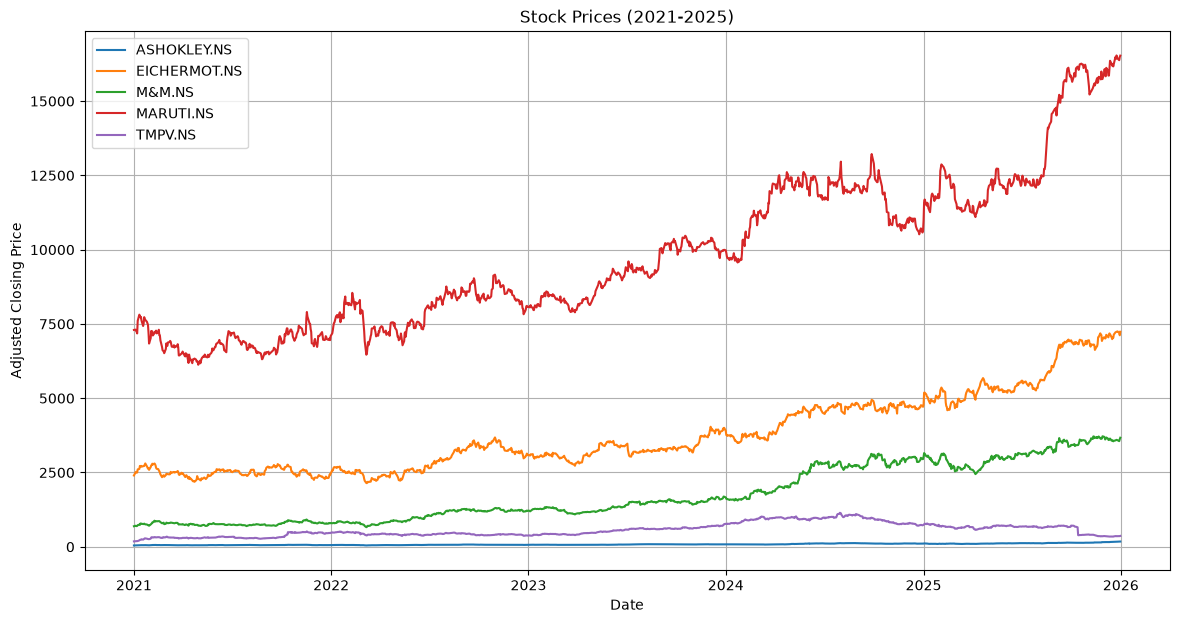

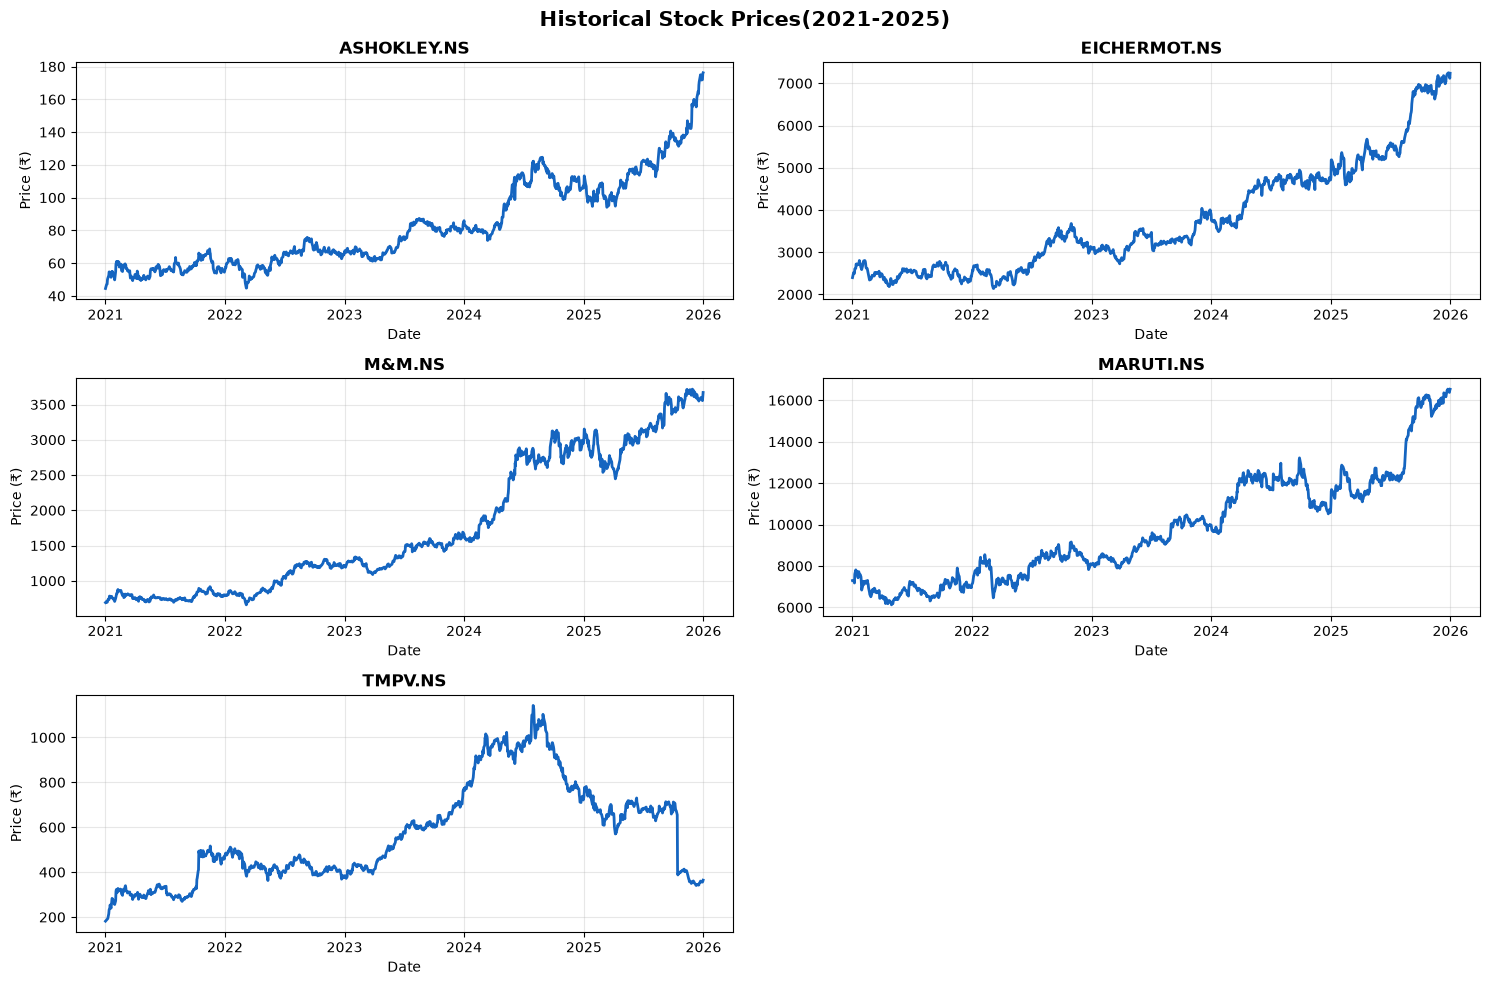

In [76]:
# Stock Price Visualization
plt.figure(figsize=(14,7))
for stock in prices.columns:
    plt.plot(prices.index, prices[stock], label=stock)
plt.title("Stock Prices (2021-2025)")
plt.xlabel("Date")
plt.ylabel("Adjusted Closing Price")
plt.legend()
plt.grid(True)
plt.show()

# Individual Stock 
fig, axes = plt.subplots(3, 2, figsize=(15,10))
axes = axes.flatten()
for ax, stock in zip(axes, prices.columns):
    ax.plot(
        prices.index,
        prices[stock],
        color="#1565C0",
        linewidth=2
    )
    ax.set_title(
        stock,
        fontweight="bold"
    )
    ax.set_xlabel("Date")
    ax.set_ylabel("Price (₹)")
    ax.grid(alpha=0.3)
for ax in axes[len(prices.columns):]:
    fig.delaxes(ax)    
plt.suptitle(
    "Historical Stock Prices(2021-2025)",
    fontsize=15,
    fontweight="bold"
)
plt.tight_layout()
plt.show()


**Observation**
- ALL stocks exhibited an overall upward trend during the study period, although the magnitude of growth varied considerably.
- TMPV.NS and MARUTI.NS stocks experienced periods of increased volatility, reflecting changing market conditions.
- While the combined chart highlights relative performance, the individual plots provide a clearer view of each stock's long-term price movement.
- MARUTI.NS showed the greatest incerease in price in the considered timeperiod. 
- TMPV.NS showed the least incerease in price in the considered timeperiod  

While the combined plot provides an overall comparison, individual stock charts make it easier to observe long-term trends that may be hidden due to differences in stock price levels.

4.3 Distribution of Stock Prices

Histograms illustrate the frequency distribution of historical stock prices. Examining these distributions helps identify whether prices are concentrated within a narrow range or spread across a wider interval.

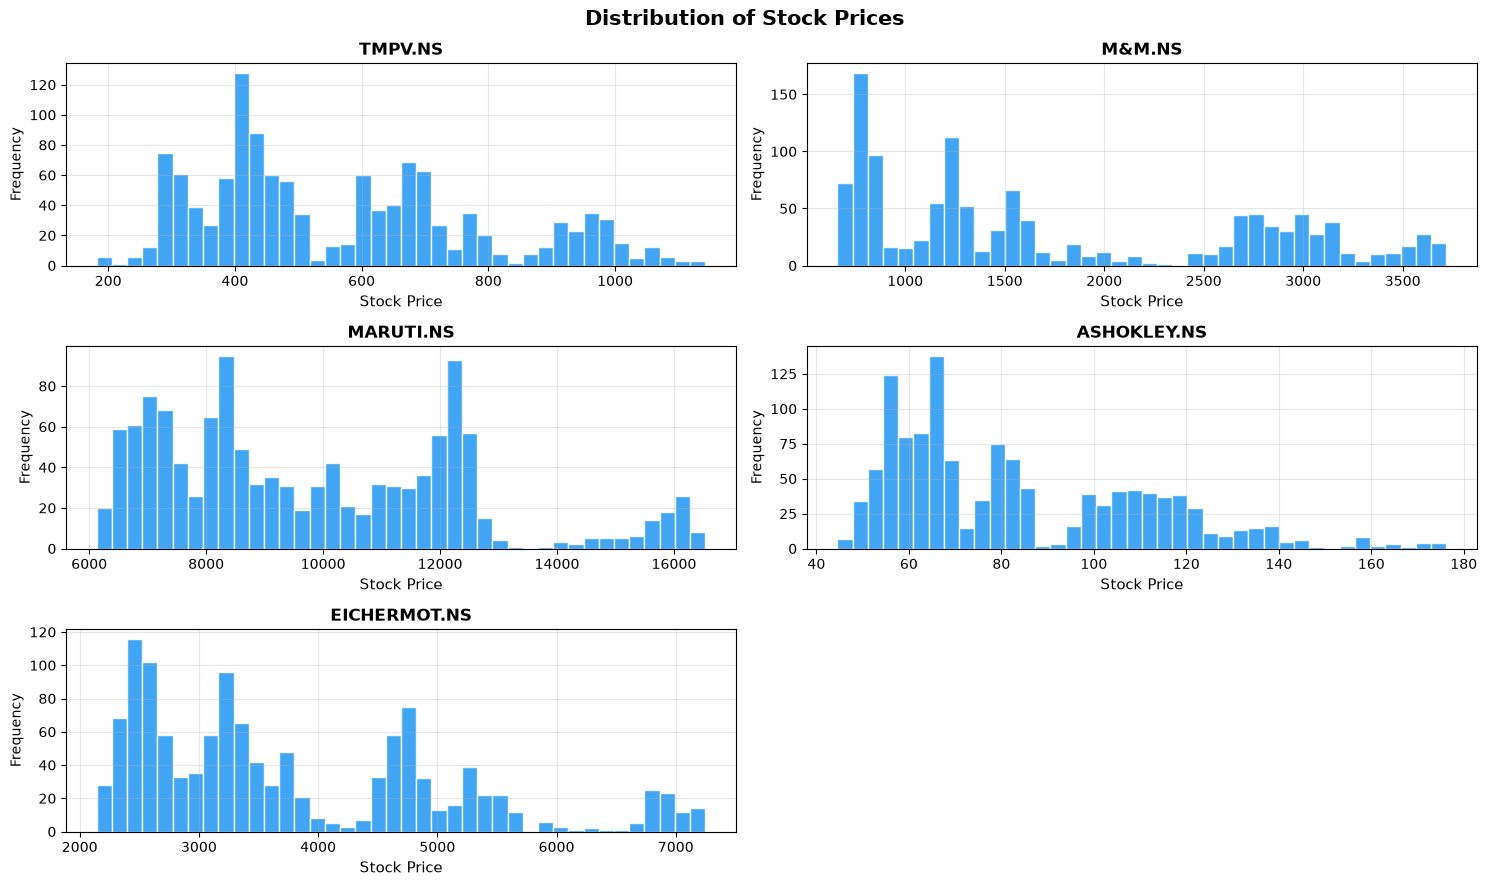

In [6]:
# Histogram for distribution price 
fig, axes = plt.subplots(3,2,figsize=(15,9))

for ax, col in zip(axes.flatten(), stocks):

    ax.hist(
        prices[col],
        bins=40,
        color='#2196F3',
        edgecolor='white',
        alpha=0.85
    )

    ax.set_title(col, fontweight='bold')
    ax.set_xlabel("Stock Price", fontsize=11)
    ax.set_ylabel("Frequency")
    ax.grid(alpha=0.3)

for ax in axes.flatten()[len(stocks):]:
    fig.delaxes(ax)

plt.suptitle(
    "Distribution of Stock Prices",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

Observation

- Stocks display a non-normal price distributions, reflecting long-term market trends rather than random fluctuations.
- Some companies exhibit a wider distribution of prices, indicating greater variability over the sample period.
- Differences in distribution highlight how individual stocks have followed distinct growth trajectories.

4.4 Boxplot Analysis

Boxplots summarize the distribution of stock prices by displaying the median, interquartile range, overall spread, and potential outliers. They provide a concise comparison of variability across companies. 

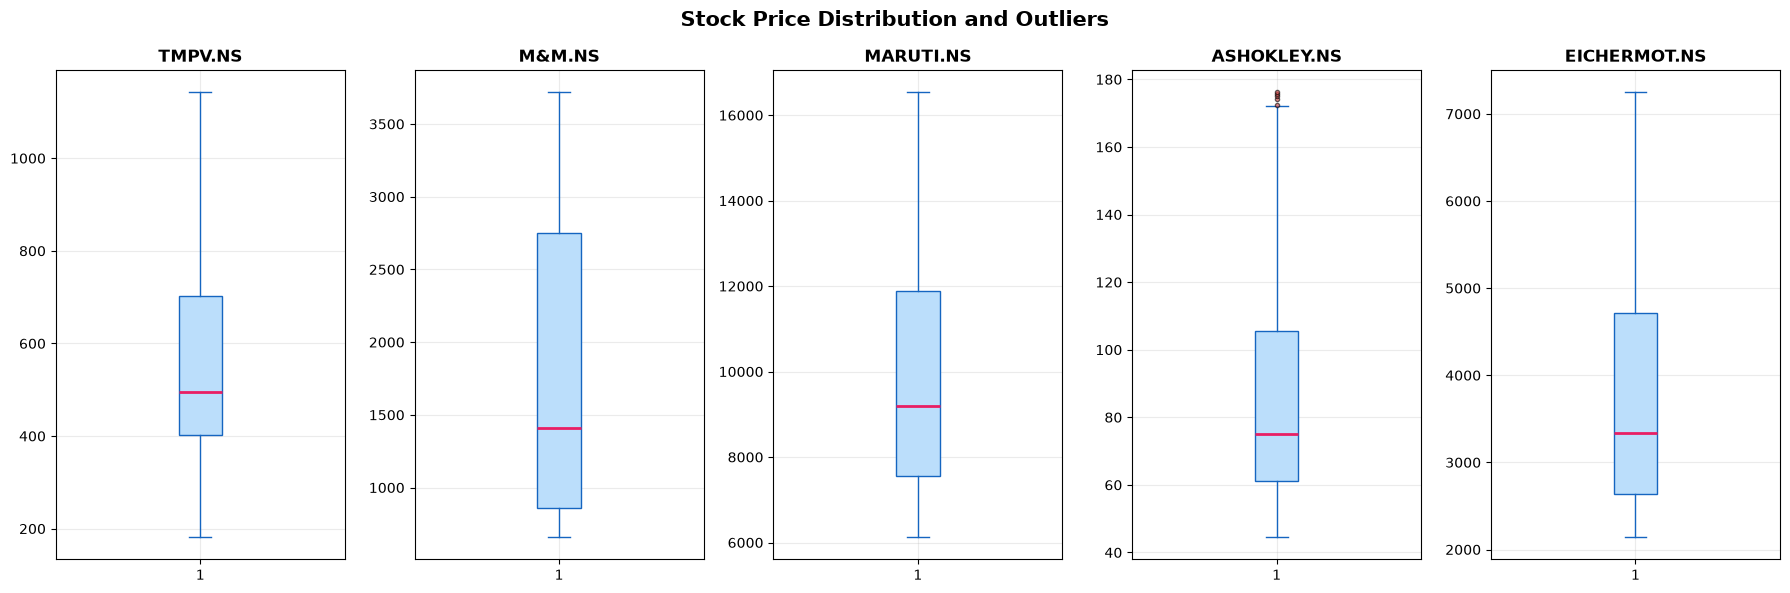

In [7]:
# Boxplots Analysis 
fig, axes = plt.subplots(1,len(stocks), figsize=(18,6))

for ax, col in zip(axes.flatten(), stocks):
    ax.boxplot(
        prices[col],
        patch_artist=True,
        boxprops=dict(facecolor="#BBDEFB",color="#1565C0"),
        medianprops=dict(color="#E91E63",linewidth=2),
        whiskerprops=dict(color="#1565C0"),
        capprops=dict(color="#1565C0"),
        flierprops=dict(
            marker='o',
            markersize=3,
            markerfacecolor="#EF5350",
            alpha=0.6
        )
    )
    ax.set_title(col,fontweight='bold')
    ax.grid(alpha=0.25)
plt.suptitle(
    "Stock Price Distribution and Outliers",
    fontsize=15,
    fontweight="bold"
)
plt.tight_layout()
plt.show()

**Observation**

- Several stocks exhibit wider interquartile ranges, indicating greater variability in historical prices. With MARUTI.NS and .EICHERMOT.NS showing the greatest. 
- Outliers are visible for some companies, reflecting periods of unusually high or low market prices.
- Differences in spread suggest that certain stocks have experienced substantially higher price volatility than others.
to see stocks with the largest spread or extreme values

4.5 Rolling Moving Average

Daily stock prices often contain short-term fluctuations that can obscure long-term market trends. A 30-day moving average smooths these fluctuations, making it easier to observe the underlying direction of each stock.

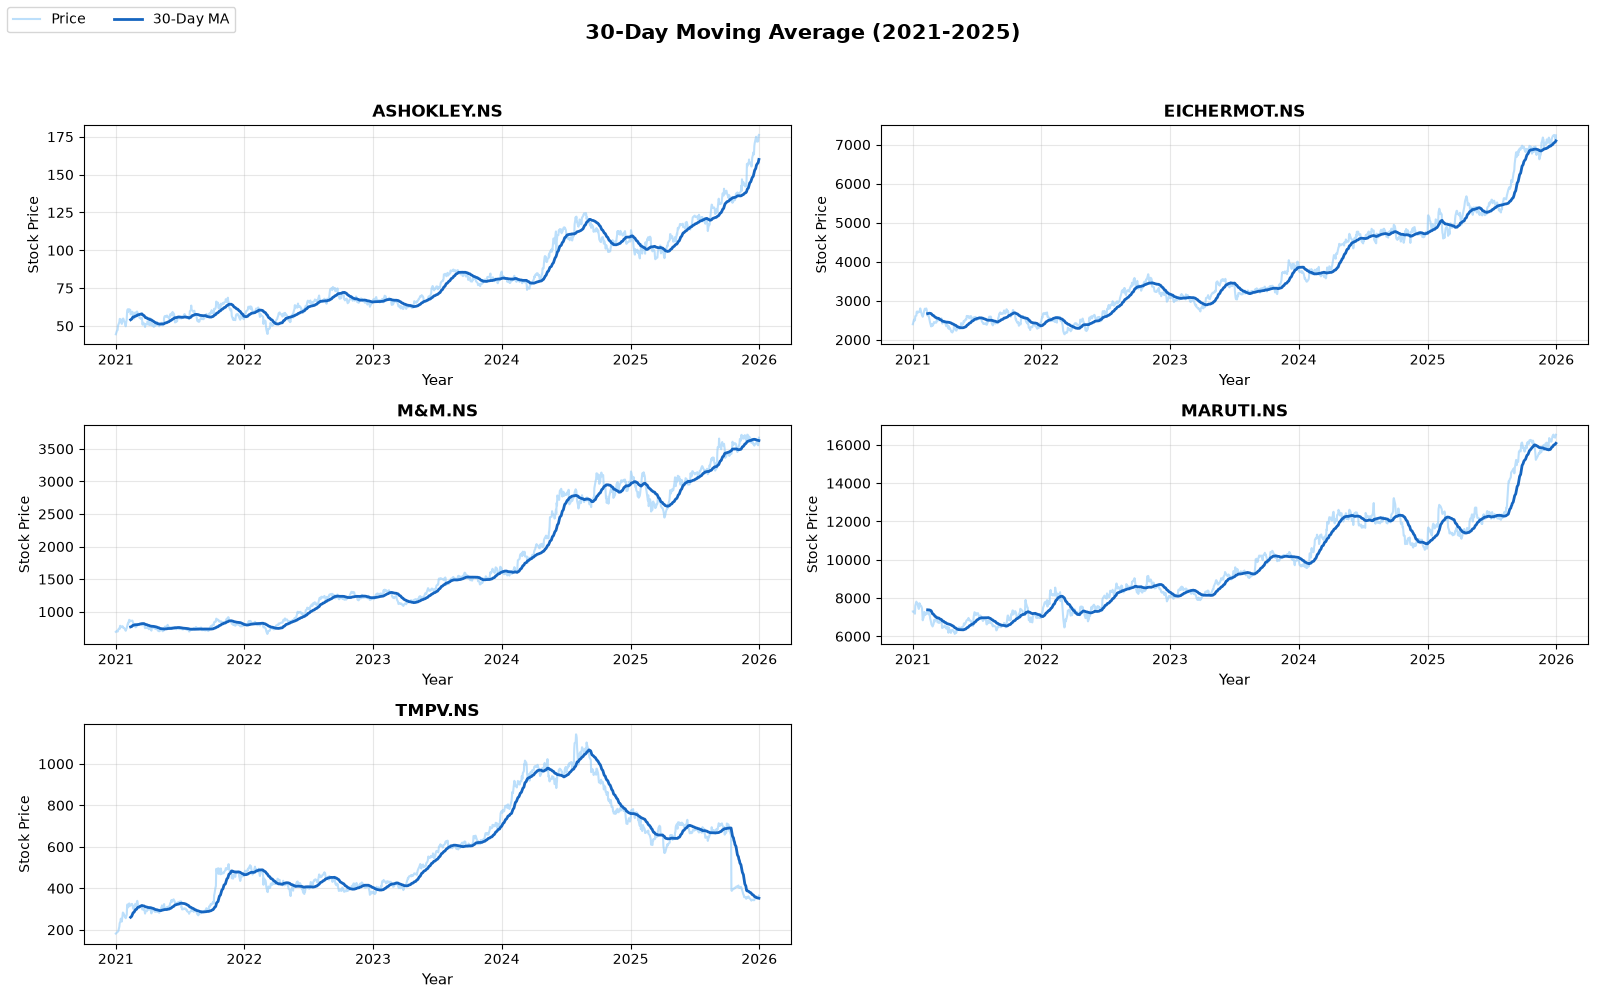

In [77]:
# Rolling Moving Average
rolling_mean = prices.rolling(30).mean()
fig, axes = plt.subplots(3,2, figsize=(16,10))
axes = axes.flatten()
for ax, stock in zip(axes, prices.columns):
    ax.plot(
        prices.index,
        prices[stock],
        label="Price",
        alpha=0.6,
        color="#90CAF9"
    )
    ax.plot(
        prices.index,
        rolling_mean[stock],
        label="30-Day MA",
        linewidth=2,
        color="#1565C0"
    )
    ax.set_title(
        stock,
        fontweight="bold"
    )
    ax.set_xlabel("Year", fontsize=11)
    ax.set_ylabel("Stock Price")
    ax.grid(alpha=0.3)
for ax in axes[len(prices.columns):]:
    fig.delaxes(ax)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper left",
    ncol=2
)
plt.suptitle(
    "30-Day Moving Average (2021-2025)",
    fontsize=15,
    fontweight="bold"
)
plt.tight_layout(rect=[0,0,1,0.95])
plt.show()



**Observation**

- The 30-day moving average successfully smooths short-term price fluctuations while preserving long-term trends.
- During periods of strong price movements, the moving average reacts more gradually, highlighting the lagging nature of this indicator.
- Overall, the moving averages confirm the broader market trends observed in the raw price data.

## 5. Return Calculations

Investment decisions are based on asset returns rather than raw stock prices. This section calculates daily percentage returns and annualized returns to evaluate the expected performance of each stock over the study period.

5.1 Daily Returns

Daily returns measure the percentage change in stock prices from one trading day to the next. They provide a standardized measure of performance, allowing meaningful comparisons across stocks with different price levels.

In [9]:
# Returns 
returns = prices.pct_change()
# Arrange returns according to the stock order used throughout the analysis
returns = returns[stocks]

In [10]:
print(returns.head())
returns.describe()
returns.isnull().sum()

Ticker       TMPV.NS    M&M.NS  MARUTI.NS  ASHOKLEY.NS  EICHERMOT.NS
Date                                                                
2021-01-01       NaN       NaN        NaN          NaN           NaN
2021-01-04  0.025737  0.022732   0.001430     0.049950      0.044441
2021-01-05  0.009932 -0.012014  -0.006083     0.006727      0.007230
2021-01-06  0.011387 -0.005405  -0.003507     0.003341     -0.011047
2021-01-07  0.006909  0.011276  -0.008199     0.056613      0.001682


Ticker
TMPV.NS         1
M&M.NS          1
MARUTI.NS       1
ASHOKLEY.NS     1
EICHERMOT.NS    1
dtype: int64

**Observation**

- The first observation contains missing values because daily returns require the previous trading day's price.
- Daily returns fluctuate around zero, reflecting normal day-to-day market movements.
- Some stocks exhibit greater variability, suggesting higher short-term volatility.

5.2 Mean Daily Returns

The average daily return represents the expected daily growth of each stock based on historical observations. It provides a simple estimate of expected return before annualization.

In [11]:
# Daily expanded (average) returns
mean_returns = returns.mean()
print(mean_returns) 

Ticker
TMPV.NS         0.000897
M&M.NS          0.001513
MARUTI.NS       0.000769
ASHOKLEY.NS     0.001313
EICHERMOT.NS    0.001027
dtype: float64


**Observation**

- M&M.NS has the highest daily mean returns and MARUTI.NS has the lowest daily mean returns
- All stocks have positive daily average returns.  
- Average daily returns differ across companies, indicating varying levels of historical performance.
- Stocks with higher average returns may offer greater growth potential but should be evaluated alongside their associated risk.

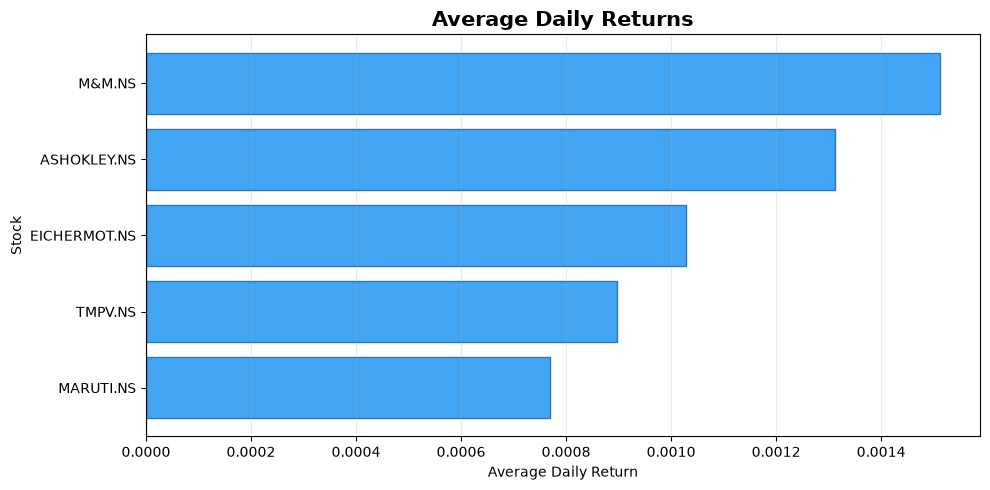

In [12]:
# Graph
# Average Daily Returns

sorted_returns = mean_returns.sort_values()

plt.figure(figsize=(10, 5))

bars = plt.barh(
    sorted_returns.index,
    sorted_returns.values,
    color="#2196F3",
    edgecolor="#1565C0",
    alpha=0.85
)

plt.title(
    "Average Daily Returns",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Average Daily Return")
plt.ylabel("Stock")

plt.axvline(0, color="black", linewidth=0.8)
plt.grid(axis="x", alpha=0.25)

plt.tight_layout()
plt.show()

Average Daily Returns

Average daily returns provide an estimate of the typical one-day performance of each stock over the sample period. Comparing these values helps identify differences in historical return characteristics across the selected equities.

5.3 Annual Returns

Daily returns are converted into annualized returns using the assumption of 252 trading days in a year. Annualization provides a more practical measure for comparing investment performance.

In [13]:
# Annualized Returns
annual_returns = (mean_returns * 252).reindex(stocks)

print(annual_returns)

Ticker
TMPV.NS         0.225999
M&M.NS          0.381169
MARUTI.NS       0.193771
ASHOKLEY.NS     0.330825
EICHERMOT.NS    0.258910
dtype: float64


**Observation**

- M&M.NS has the highest annual mean returns and MARUTI.NS has the lowest annual mean returns
- All stocks have positive annual average returns.  
- Annualized returns provide a standardized estimate of expected yearly performance.
- Historical returns should be interpreted as estimates rather than guarantees of future performance.

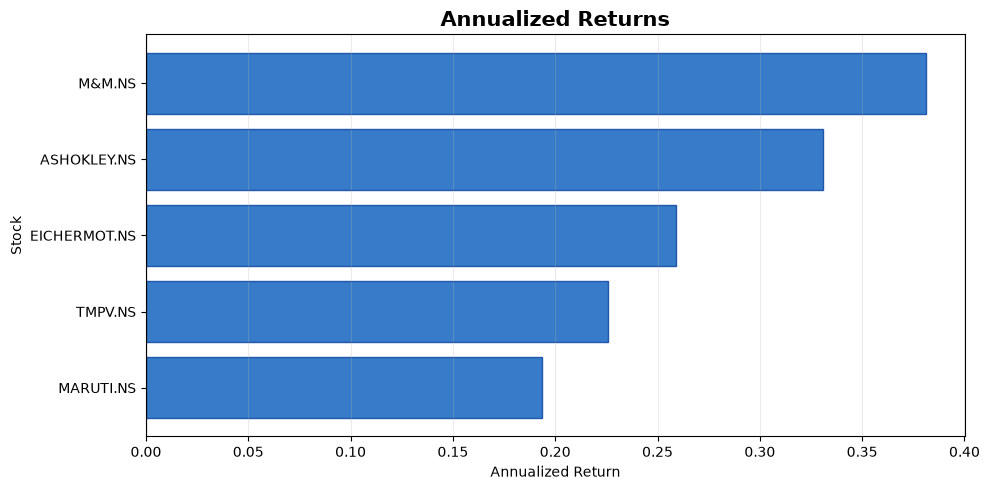

In [14]:
# Graph
# Annualized Returns

sorted_annual_returns = annual_returns.sort_values()

plt.figure(figsize=(10, 5))

plt.barh(
    sorted_annual_returns.index,
    sorted_annual_returns.values,
    color="#1565C0",
    edgecolor="#0D47A1",
    alpha=0.85
)

plt.title(
    "Annualized Returns",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Annualized Return")
plt.ylabel("Stock")

plt.axvline(0, color="black", linewidth=0.8)
plt.grid(axis="x", alpha=0.25)

plt.tight_layout()
plt.show()


5.4 Cumulative Returns 

Cumulative returns show how an initial investment would have grown over the study period based on the daily returns of each stock. Unlike individual daily returns, cumulative returns capture the effect of compounding and provide a clearer view of long-term investment performance.

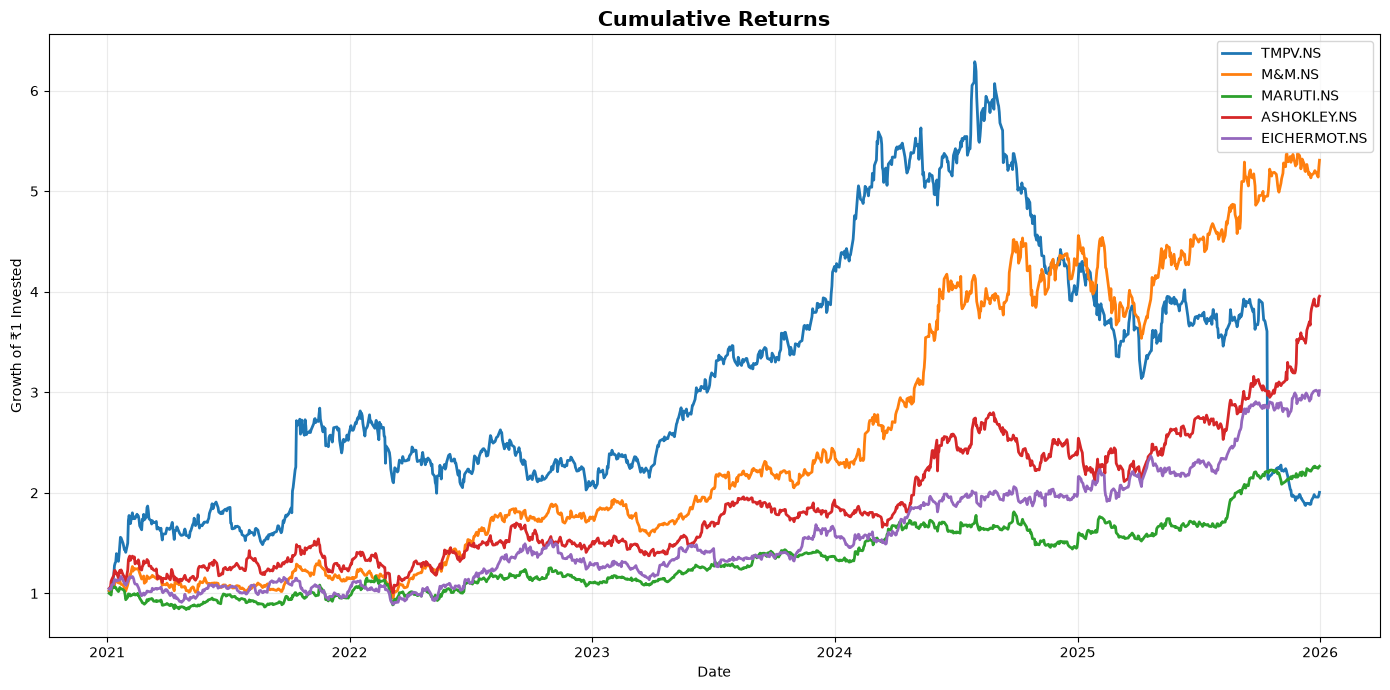

In [ ]:
# Cumulative Returns

cumulative_returns = (1 + returns).cumprod()

plt.figure(figsize=(14, 7))

for stock in cumulative_returns.columns:
    plt.plot(
        cumulative_returns.index,
        cumulative_returns[stock],
        linewidth=2,
        label=stock
    )

plt.title(
    "Cumulative Returns (2021-2025)",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Date")
plt.ylabel("Growth of ₹1 Invested")
plt.legend()
plt.grid(alpha=0.25)

plt.tight_layout()
plt.show()

**Observation**

- Cumulative performance differs considerably across the selected stocks over the study period.
- M&M.NS is the stock with the highest ending cumulative value generated and the strongest compounded growth over the sample period.
- TMPV.NS and MARUTI.NS were the stock with the lower ending cumulative value generated and a lower compounded growth over the sample period.
- Differences in cumulative performance highlight why historical average returns alone may not fully capture an investment's long-term growth trajectory.

## 6. Risk Analysis

Expected returns should always be evaluated alongside investment risk. This section measures the variability of returns, relationships between assets, and overall portfolio risk using statistical and financial risk metrics.

6.1 Daily Volatility

Volatility is measured as the standard deviation of daily returns. Higher volatility indicates greater uncertainty and larger fluctuations in investment performance.

In [17]:
# Risk (volatility)
daily_volatility = returns.std()
print(daily_volatility)

daily_volatility.describe()
daily_volatility.isnull().sum()


Ticker
TMPV.NS         0.024960
M&M.NS          0.017930
MARUTI.NS       0.014649
ASHOKLEY.NS     0.019968
EICHERMOT.NS    0.016357
dtype: float64


np.int64(0)

**Observation**

- TMPV.NS has the highest daily volatility and MARUTI.NS has the lowest daily volatility
- Stocks with higher standard deviations exhibit greater day-to-day price fluctuations.
- Higher volatility generally implies higher investment risk.

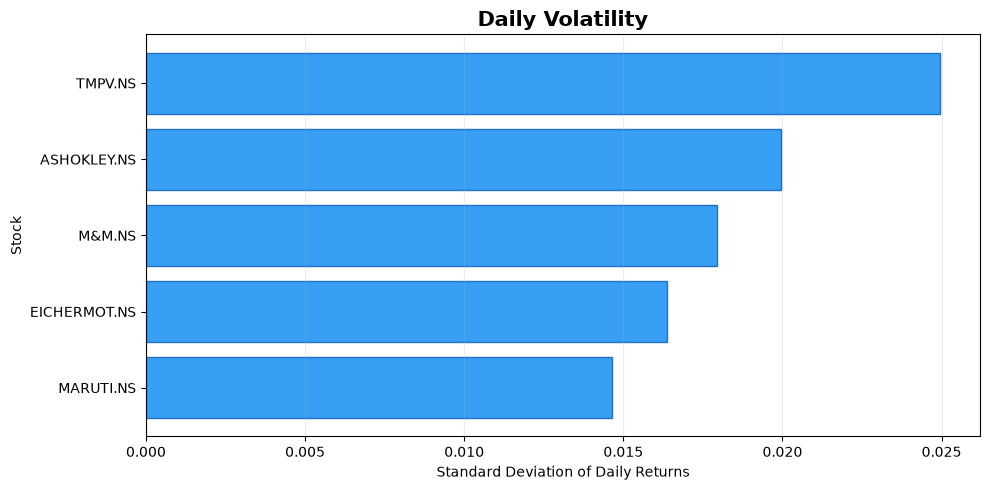

In [18]:
# Graph
# Daily Volatility

sorted_daily_volatility = daily_volatility.sort_values()

plt.figure(figsize=(10, 5))

plt.barh(
    sorted_daily_volatility.index,
    sorted_daily_volatility.values,
    color="#2196F3",
    edgecolor="#1565C0",
    alpha=0.9
)

plt.title(
    "Daily Volatility",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Standard Deviation of Daily Returns")
plt.ylabel("Stock")

plt.grid(axis="x", alpha=0.25)

plt.tight_layout()
plt.show()

6.2 Annualized Volatility (Risk)

Daily volatility is annualized using the square root of time rule, allowing direct comparison with annualized returns.

In [19]:
# Annual Risk 
annual_volatility = daily_volatility*np.sqrt(252)
print(annual_volatility)

Ticker
TMPV.NS         0.396221
M&M.NS          0.284631
MARUTI.NS       0.232539
ASHOKLEY.NS     0.316988
EICHERMOT.NS    0.259659
dtype: float64


**Observation**

- TMPV.NS has the highest annual volatility and MARUTI.NS has the lowest annual volatility
- Stocks with higher standard deviations exhibit greater year to year price fluctuations.

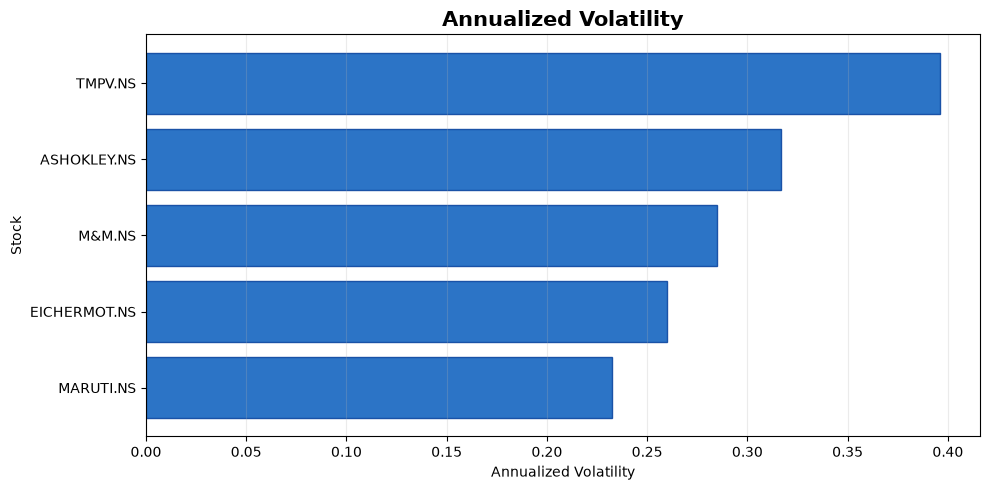

In [20]:
# Graph
# Annualized Volatility

sorted_annual_volatility = annual_volatility.sort_values()

plt.figure(figsize=(10, 5))

plt.barh(
    sorted_annual_volatility.index,
    sorted_annual_volatility.values,
    color="#1565C0",
        edgecolor="#0D47A1",
    alpha=0.9
)

plt.title(
    "Annualized Volatility",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Annualized Volatility")
plt.ylabel("Stock")

plt.grid(axis="x", alpha=0.25)

plt.tight_layout()
plt.show()

6.3 Covariance Matrix

The covariance matrix measures how stock returns move together. It forms one of the primary inputs in Modern Portfolio Theory for calculating overall portfolio risk.

In [ ]:
# cov 
cov_matrix = returns.cov()
cov_matrix

Ticker,TMPV.NS,M&M.NS,MARUTI.NS,ASHOKLEY.NS,EICHERMOT.NS
Ticker,,,,,
TMPV.NS,0.000623,0.000191,0.000133,0.000259,0.000137
M&M.NS,0.000191,0.000321,0.000118,0.000165,0.000127
MARUTI.NS,0.000133,0.000118,0.000215,0.000118,0.000113
ASHOKLEY.NS,0.000259,0.000165,0.000118,0.000399,0.000133
EICHERMOT.NS,0.000137,0.000127,0.000113,0.000133,0.000268


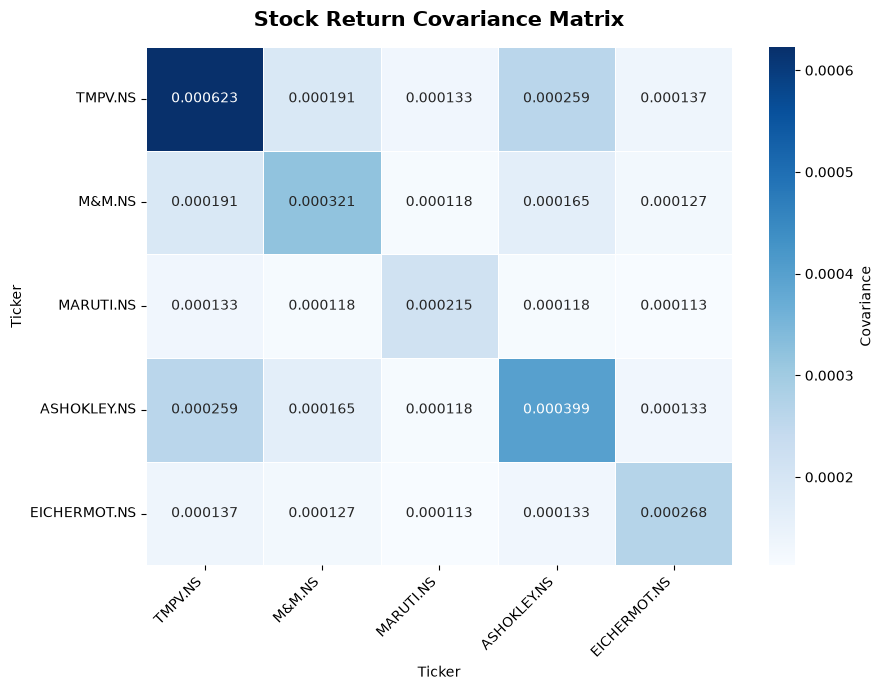

In [22]:
# COVariance Heatmap
import seaborn as sns
plt.figure(figsize=(9, 7))

sns.heatmap(
    cov_matrix,
    annot=True,
    fmt=".6f",
    cmap="Blues",
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Covariance"}
)

plt.title(
    "Stock Return Covariance Matrix",
    fontsize=15,
    fontweight="bold",
    pad=15
)

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

6.4 Correlation Matrix

Correlation measures the strength and direction of relationships between stock returns. Diversification benefits increase when correlations between assets are relatively low.

In [23]:
# corr
corr_matrix = returns.corr()
corr_matrix

Ticker,TMPV.NS,M&M.NS,MARUTI.NS,ASHOKLEY.NS,EICHERMOT.NS
Ticker,,,,,
TMPV.NS,1.000000,0.425815,0.362519,0.519085,0.335719
M&M.NS,0.425815,1.000000,0.450580,0.460403,0.433102
MARUTI.NS,0.362519,0.450580,1.000000,0.402008,0.472172
ASHOKLEY.NS,0.519085,0.460403,0.402008,1.000000,0.406927
EICHERMOT.NS,0.335719,0.433102,0.472172,0.406927,1.000000


- Highest correlation: ASHOKLEY–TMPV = 0.519
- Lowest correlation: EICHERMOT–TMPV = 0.336
- Most relationships are around 0.36–0.52

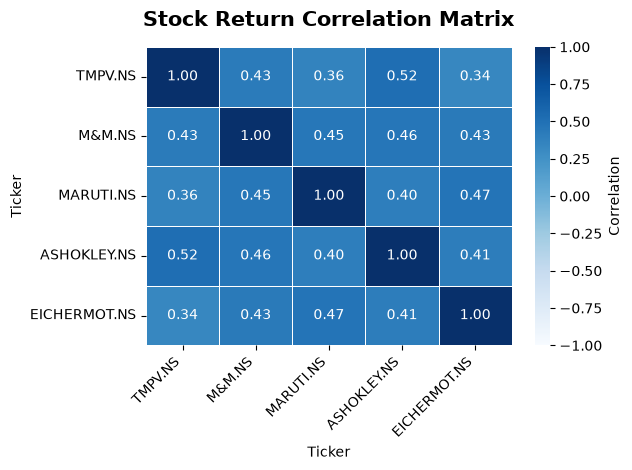

In [24]:
# Heatmap corr matrix
import seaborn as sns
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Correlation"}
)

plt.title(
    "Stock Return Correlation Matrix",
    fontsize=15,
    fontweight="bold",
    pad=15
)

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

**Observation**

- All five stocks exhibit positive correlations with one another, indicating that their returns generally move in the same direction.
- The correlations are moderate rather than extremely high, ranging from approximately 0.34 to 0.52.
- The highest correlation is observed between ASHOKLEY.NS and TMPV.NS, while the lowest is between EICHERMOT.NS and TMPV.NS.
- The absence of very high correlations suggests that combining these stocks can provide diversification benefits.

6.5 Portfolio Return and Risk

An equally weighted portfolio is constructed to estimate the combined expected return and overall risk of the selected stocks. Portfolio risk depends not only on the volatility of individual assets but also on the relationships between them.

In [25]:
# Portfolio Risk and Returns 
# Equal-Weight Portfolio

weights_p = np.array([0.2, 0.2, 0.2, 0.2, 0.2])

# Expected daily portfolio return
portfolio_return = np.sum(weights_p * mean_returns)

# Portfolio variance
portfolio_variance = np.dot(
    weights_p.T,
    np.dot(cov_matrix, weights_p)
)

# Portfolio daily volatility
portfolio_daily_volatility = np.sqrt(portfolio_variance)

# Annualized metrics
portfolio_annual_return = portfolio_return * 252
portfolio_annual_volatility = portfolio_daily_volatility * np.sqrt(252)

print("Expected Daily Portfolio Return :", portfolio_return)
print("Daily Portfolio Volatility      :", portfolio_daily_volatility)
print("Portfolio Variance               :", portfolio_variance)
print("Annualized Portfolio Return     :", portfolio_annual_return)
print("Annualized Portfolio Volatility :", portfolio_annual_volatility)

Expected Daily Portfolio Return : 0.0011037097298250212
Daily Portfolio Volatility      : 0.013871959132287497
Portfolio Variance               : 0.0001924312501678545
Annualized Portfolio Return     : 0.27813485191590537
Annualized Portfolio Volatility : 0.22021052436770439


6.6 Sharpe Ratio

The Sharpe Ratio evaluates risk-adjusted performance by measuring excess return earned for each unit of portfolio risk. A higher Sharpe Ratio indicates greater return generated per unit of risk.

For this analysis, a 0% annual risk-free rate is assumed for simplicity.

In [26]:
# Sharpe Ratio
annual_portfolio_return = portfolio_return * 252
annual_portfolio_volatility = portfolio_daily_volatility * np.sqrt(252)

# Assumption: 0% annual risk-free rate
risk_free_rate = 0


portfolio_sharpe_ratio = (
    annual_portfolio_return - risk_free_rate
) / annual_portfolio_volatility

print("Annual Portfolio Return :", annual_portfolio_return)
print("Annual Portfolio Volatility   :", annual_portfolio_volatility)
print("Portfolio Sharpe Ratio            :", portfolio_sharpe_ratio)

Annual Portfolio Return : 0.27813485191590537
Annual Portfolio Volatility   : 0.22021052436770439
Portfolio Sharpe Ratio            : 1.2630406866997863


**Observation**

- The equally weighted portfolio generated an annualized historical return of approximately 27.81% with annualized volatility of approximately 22.02%.
- Under the assumption of a 0% risk-free rate, the portfolio produced a Sharpe Ratio of approximately 1.26.
- This indicates that the portfolio generated approximately 1.26 units of annualized return for each unit of volatility under the assumptions used.
- The Sharpe Ratio will serve as an important benchmark when comparing the optimized portfolios in the subsequent portfolio optimization stage.

Equal-weight portfolio
- Return: 27.81%
- Risk: 22.02%
- Sharpe: 1.26

## 7. Portfolio Optimization

Modern Portfolio Theory seeks to identify portfolio allocations that provide an efficient trade-off between expected return and risk. In this section, thousands of possible asset-weight combinations are simulated to evaluate how different allocations affect portfolio return, volatility, and risk-adjusted performance.

The simulated portfolios are then compared to identify portfolios that maximize expected return, maximize the Sharpe Ratio, and minimize portfolio risk. These results are visualized through the Efficient Frontier to illustrate the relationship between risk and return.

**Portfolio Optimization obhectives**

Portfolio optimization aims to identify asset allocations that provide an efficient balance between expected return and risk. Using the historical return and covariance estimates calculated earlier, portfolio-level return and risk can be evaluated for different combinations of asset weights.

The analysis begins with the generation of multiple possible portfolio allocations, which are subsequently evaluated to identify portfolios with different investment objectives.

## 8. Monte Carlo Portfolio Simulation

To explore the range of possible portfolio outcomes, 10,000 portfolios are generated using randomly assigned asset weights. The weights are normalized so that each portfolio is fully invested, with total weights equal to 100%.

For each simulated portfolio, annualized expected return, annualized volatility, and the Sharpe Ratio are calculated. The resulting portfolio combinations are then used to identify portfolios that perform best under different investment objectives.

8.1 Monte Carlo Portfolio Simulation

A Monte Carlo simulation is used to generate 10,000 randomly weighted portfolios. For each portfolio, asset weights are generated and normalized so that the total allocation equals 100%. Expected return, volatility, and Sharpe Ratio are then calculated for each simulated portfolio.

This approach allows a large number of possible portfolio allocations to be evaluated without manually testing individual combinations.

In [27]:
# 10,000 random portfolios
num_portfolios = 10000
results = []

for i in range(num_portfolios):

    weights = np.random.random(len(stocks))
    weights = weights / np.sum(weights)

    portfolio_return = np.sum(weights * annual_returns)

    portfolio_variance = np.dot(
        weights.T,
        np.dot(cov_matrix * 252, weights)
    )

    portfolio_volatility = np.sqrt(portfolio_variance)

    sharpe_ratio = portfolio_return / portfolio_volatility

    results.append([
        portfolio_return,
        portfolio_volatility,
        sharpe_ratio,
        *weights
    ])

8.2 Simulated Portfolio Results

The simulation produces a dataset containing the asset weights and corresponding performance metrics for each portfolio. These results provide the basis for identifying the most attractive portfolio allocations under different investment objectives.

In [28]:
# Random Portfolios Dataframe
results_df = pd.DataFrame(
    results,
    columns=[
        "Return",
        "Volatility",
        "Sharpe",
        *stocks
    ]
)

In [29]:
#
print("Number of simulated portfolios:", len(results_df))
results_df.head()

Number of simulated portfolios: 10000


,Return,Volatility,Sharpe,TMPV.NS,M&M.NS,MARUTI.NS,ASHOKLEY.NS,EICHERMOT.NS
0,0.253092,0.249436,1.014658,0.399343,0.106420,0.270719,0.166149,0.057369
1,0.296975,0.214231,1.386239,0.059060,0.381903,0.143187,0.036774,0.379077
2,0.264562,0.221853,1.192510,0.259683,0.245221,0.301234,0.053392,0.140471
3,0.308919,0.223430,1.382617,0.129255,0.460762,0.136429,0.094794,0.178760
4,0.301822,0.238097,1.267643,0.236944,0.279450,0.034562,0.261368,0.187676


In [ ]:
# Chech One Portfolio 
results_df.sample(1)

,Return,Volatility,Sharpe,TMPV.NS,M&M.NS,MARUTI.NS,ASHOKLEY.NS,EICHERMOT.NS
7600,0.281333,0.29764,0.945212,0.566255,0.245021,0.016326,0.169179,0.003219


Observation 

The simulation produces a portfolio dataset containing the expected return, risk, Sharpe Ratio, and asset weights for each of the 10,000 portfolios. 

This dataset allows the simulated portfolios to be ranked according to different optimization objectives.

The simulation demonstrates that different asset allocations produce substantially different combinations of expected return, volatility, and Sharpe Ratio. This variation provides a range of portfolios from which optimal allocations can be identified.

8.3 Identifying Optimal Portfolios

The simulated portfolios are ranked according to three different investment objectives: maximizing risk-adjusted return, minimizing portfolio risk, and maximizing expected return. 

Maximum Return Portfolio

The maximum return portfolio is the simulated portfolio with the highest expected return. Its asset allocation is examined to understand which combination of stocks produced the highest estimated return.

In [ ]:
# To find portfolio with max returns
max_return = results_df.loc[results_df["Return"].idxmax()]

print("Maximum Returns Portfolio")
print("-" * 40)
print(f"Expected Return : {max_return['Return']:.2%}")
print(f"Volatility      : {max_return['Volatility']:.2%}")
print(f"Sharpe Ratio    : {max_return['Sharpe']:.2f}")
print("\nPortfolio Weights:")
print(max_return[stocks].map(lambda x: f"{x:.2%}"))

Maximum Returns Portfolio
----------------------------------------
Expected Return : 34.42%
Volatility      : 24.80%
Sharpe Ratio    : 1.39

Portfolio Weights:
TMPV.NS          1.04%
M&M.NS          42.17%
MARUTI.NS        1.29%
ASHOKLEY.NS     48.56%
EICHERMOT.NS     6.94%
Name: 1932, dtype: str


Maximum Sharpe Ratio Portfolio

The Maximum Sharpe Ratio portfolio is the simulated portfolio that provides the highest risk-adjusted return. Rather than maximizing return alone, this portfolio considers both expected return and volatility to identify the most efficient risk-return combination among the simulated portfolios.

In [33]:
# To find portfolio with max sharpe ratio
max_sharpe = results_df.loc[results_df["Sharpe"].idxmax()]

print("Maximum Sharpe Ratio Portfolio")
print("-" * 40)
print(f"Expected Return : {max_sharpe['Return']:.2%}")
print(f"Volatility      : {max_sharpe['Volatility']:.2%}")
print(f"Sharpe Ratio    : {max_sharpe['Sharpe']:.2f}")
print("\nPortfolio Weights:")
print(max_sharpe[stocks].map(lambda x: f"{x:.2%}"))

Maximum Sharpe Ratio Portfolio
----------------------------------------
Expected Return : 33.21%
Volatility      : 22.75%
Sharpe Ratio    : 1.46

Portfolio Weights:
TMPV.NS          0.40%
M&M.NS          49.08%
MARUTI.NS        0.53%
ASHOKLEY.NS     19.04%
EICHERMOT.NS    30.94%
Name: 1864, dtype: str


Minimum Variance Portfolio

The Minimum Variance portfolio is the simulated portfolio with the lowest estimated volatility. Its objective is to minimize portfolio risk rather than maximize expected return.

In [34]:
# To find portfolio with min volatility
min_volatility = results_df.loc[results_df["Volatility"].idxmin()]

print("Maximum Sharpe Ratio Portfolio")
print("-" * 40)
print(f"Expected Return : {min_volatility['Return']:.2%}")
print(f"Volatility            : {min_volatility['Volatility']:.2%}")
print(f"Sharpe Ratio    : {min_volatility['Sharpe']:.2f}")
print("\nPortfolio Weights:")
print(min_volatility[stocks].map(lambda x: f"{x:.2%}"))

Maximum Sharpe Ratio Portfolio
----------------------------------------
Expected Return : 25.48%
Volatility            : 20.10%
Sharpe Ratio    : 1.27

Portfolio Weights:
TMPV.NS          1.52%
M&M.NS          16.05%
MARUTI.NS       44.01%
ASHOKLEY.NS      7.51%
EICHERMOT.NS    30.90%
Name: 5281, dtype: str


## 9. Efficient Frontier
Simulated Efficient Frontier — Monte Carlo Portfolio Optimization

The Efficient Frontier represents the portfolios that offer the highest expected return for a given level of risk. Portfolios below the frontier are considered inefficient because another portfolio can provide a higher expected return for the same or lower level of risk.

The simulated portfolios are plotted according to their expected return and volatility, with the Maximum Sharpe Ratio and Minimum Variance portfolios highlighted.


Text(0.5, 1.0, 'Efficient Frontier (Monte Carlo Simulation)')

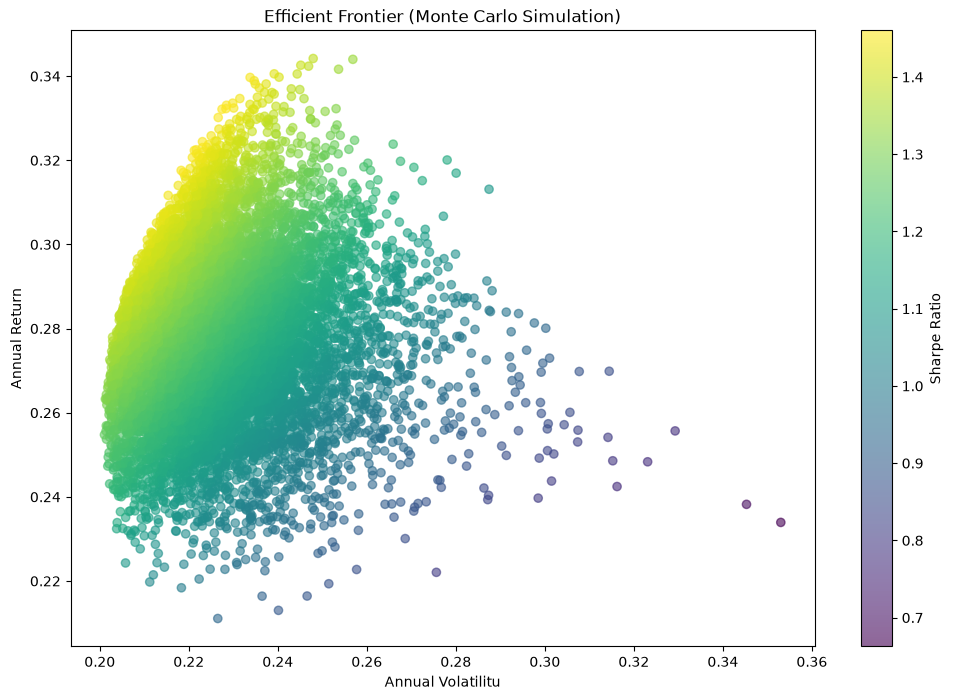

In [35]:
# Simulated Efficient Frontier — Monte Carlo Portfolio Optimization
plt.figure(figsize=(12,8))

plt.scatter(
    results_df["Volatility"],
    results_df["Return"],
    c=results_df["Sharpe"],
    cmap="viridis",
    alpha=0.6
)

plt.colorbar(label="Sharpe Ratio")

plt.xlabel("Annual Volatilitu")
plt.ylabel("Annual Return")
plt.title("Efficient Frontier (Monte Carlo Simulation)")

**Observation**

- The 10,000 simulated portfolios span annualized returns of approximately 22%–36% and annualized risk of approximately 20%–32%.
- The highest Sharpe Ratios are concentrated toward the upper-left region of the distribution, representing portfolios that achieve relatively high returns without taking proportionally higher levels of risk.
- The Maximum Sharpe portfolio generates an expected annual return of approximately 32.88% with 22.50% annualized risk and a Sharpe Ratio of 1.46.
- The Minimum Variance portfolio reduces annualized risk to approximately 20.12%, but its expected return falls to approximately 26.17%.
- The results illustrate the fundamental risk-return trade-off: pursuing higher expected returns generally requires accepting greater portfolio risk.

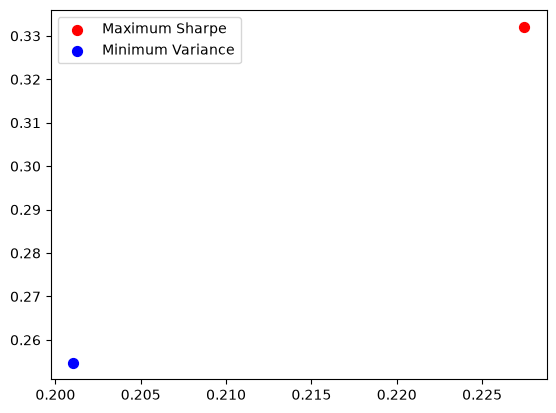

In [36]:
# graph 2 Highlighting Max Sharpe and Min Volatility
plt.scatter(
    max_sharpe["Volatility"],
    max_sharpe["Return"],
    color="red",
    marker=".",
    s=200,
    label="Maximum Sharpe"
)

plt.scatter(
    min_volatility["Volatility"],
    min_volatility["Return"],
    color="blue",
    marker=".",
    s=200,
    label="Minimum Variance"
)
plt.legend()
plt.show()

## 10. Portfolio Allocation

The optimal portfolios identified through the Monte Carlo simulation are examined in terms of their asset allocation. Comparing portfolio weights provides insight into how the optimization process changes the composition of the portfolio relative to an equally weighted benchmark.

10.1 Maximum Sharpe Portfolio Allocation

The Maximum Sharpe Ratio portfolio is the allocation that provides the highest risk-adjusted return among the 10,000 simulated portfolios. Examining its asset weights shows how the optimization process allocates capital to achieve the strongest Sharpe Ratio.

In [37]:
# Maximum Sharpe Portfolio Allocation

max_sharpe_allocation = pd.DataFrame({
    "Stock": stocks,
    "Weight": max_sharpe[stocks].values
})

max_sharpe_allocation["Weight (%)"] = (
    max_sharpe_allocation["Weight"] * 100
)

max_sharpe_allocation = max_sharpe_allocation.sort_values(
    by="Weight (%)",
    ascending=False
)

max_sharpe_allocation

,Stock,Weight,Weight (%)
1,M&M.NS,0.490831,49.083130
4,EICHERMOT.NS,0.309442,30.944240
3,ASHOKLEY.NS,0.190432,19.043189
2,MARUTI.NS,0.005314,0.531355
0,TMPV.NS,0.003981,0.398086


In [38]:
max_sharpe_display = max_sharpe_allocation.copy()

max_sharpe_display["Weight (%)"] = (
    max_sharpe_display["Weight (%)"].round(2)
)

max_sharpe_display

,Stock,Weight,Weight (%)
1,M&M.NS,0.490831,49.08
4,EICHERMOT.NS,0.309442,30.94
3,ASHOKLEY.NS,0.190432,19.04
2,MARUTI.NS,0.005314,0.53
0,TMPV.NS,0.003981,0.40


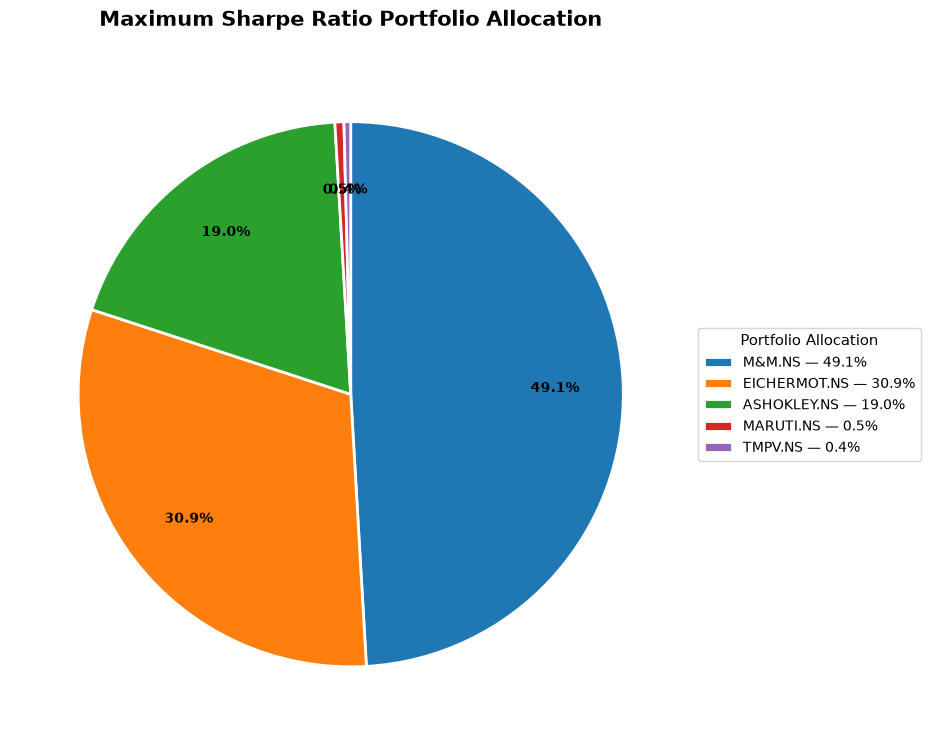

In [ ]:
# Maximum Sharpe Portfolio - Allocation Pie Chart

plt.figure(figsize=(9, 8))

wedges, texts, autotexts = plt.pie(
    max_sharpe_allocation["Weight (%)"],
    labels=None,                      
    autopct="%1.1f%%",
    startangle=90,
    counterclock=False,
    pctdistance=0.75,
    wedgeprops={
        "edgecolor": "white",
        "linewidth": 2
    },
    textprops={
        "fontsize": 10,
        "fontweight": "bold"
    }
)

legend_labels = [
    f"{stock} — {weight:.1f}%"
    for stock, weight in zip(
        max_sharpe_allocation["Stock"],
        max_sharpe_allocation["Weight (%)"]
    )
]

plt.legend(
    wedges,
    legend_labels,
    title="Portfolio Allocation",
    loc="center left",
    bbox_to_anchor=(1, 0.5),
    fontsize=10,
    title_fontsize=11
)

plt.title(
    "Maximum Sharpe Ratio Portfolio Allocation",
    fontsize=15,
    fontweight="bold",
    pad=20
)

plt.tight_layout()
plt.show()

10.2 Minimum Variance Portfolio Allocation

The Minimum Variance portfolio is the allocation that produces the lowest estimated portfolio volatility among the simulated portfolios. Its asset weights illustrate how diversification can be used to reduce overall portfolio risk.

In [40]:
# Minimum Variance Portfolio Allocation

min_variance_allocation = pd.DataFrame({
    "Stock": stocks,
    "Weight": min_volatility[stocks].values
})

min_variance_allocation["Weight (%)"] = (
    min_variance_allocation["Weight"] * 100
)

min_variance_allocation = min_variance_allocation.sort_values(
    by="Weight (%)",
    ascending=False
)

min_variance_display = min_variance_allocation.copy()

min_variance_display["Weight (%)"] = (
    min_variance_display["Weight (%)"].round(2)
)

min_variance_display

,Stock,Weight,Weight (%)
2,MARUTI.NS,0.440089,44.01
4,EICHERMOT.NS,0.309026,30.90
1,M&M.NS,0.160522,16.05
3,ASHOKLEY.NS,0.075128,7.51
0,TMPV.NS,0.015235,1.52


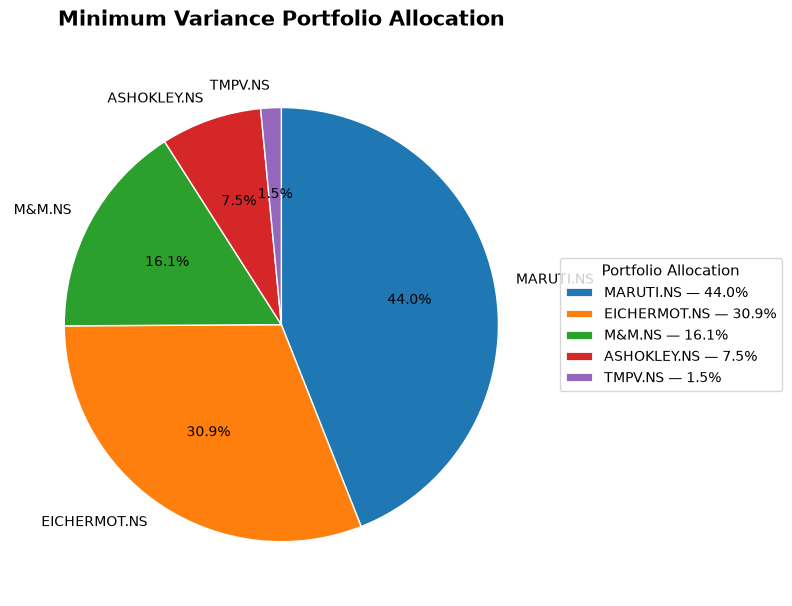

In [80]:
# Minimum Variance Portfolio - Allocation Donut Chart

plt.figure(figsize=(8, 8))

plt.pie(
    min_variance_allocation["Weight (%)"],
    labels=min_variance_allocation["Stock"],
    autopct="%1.1f%%",
    startangle=90,
    counterclock=False,
    wedgeprops={
        "edgecolor": "white"
    },
    textprops={
        "fontsize": 10
    }
)
legend_labels = [
    f"{stock} — {weight:.1f}%"
    for stock, weight in zip(
        min_variance_allocation["Stock"],
        min_variance_allocation["Weight (%)"]
    )
]

plt.legend(
    wedges,
    legend_labels,
    title="Portfolio Allocation",
    loc="center left",
    bbox_to_anchor=(1, 0.5),
    fontsize=10,
    title_fontsize=11
)
plt.title(
    "Minimum Variance Portfolio Allocation",
    fontsize=15,
    fontweight="bold",
    pad=20
)

plt.tight_layout()
plt.show()

10.3 Maximum Return Portfolio Allocation

The Maximum Return portfolio represents the simulated allocation with the highest expected annual return. Unlike the Maximum Sharpe Ratio portfolio, this allocation prioritizes expected return without directly optimizing for risk-adjusted performance.

In [42]:
# Maximum Return Portfolio Allocation

max_return_allocation = pd.DataFrame({
    "Stock": stocks,
    "Weight": max_return[stocks].values
})

max_return_allocation["Weight (%)"] = (
    max_return_allocation["Weight"] * 100
)

max_return_allocation = max_return_allocation.sort_values(
    by="Weight (%)",
    ascending=False
)

max_return_display = max_return_allocation.copy()

max_return_display["Weight (%)"] = (
    max_return_display["Weight (%)"].round(2)
)

max_return_display

,Stock,Weight,Weight (%)
3,ASHOKLEY.NS,0.485604,48.56
1,M&M.NS,0.421651,42.17
4,EICHERMOT.NS,0.069375,6.94
2,MARUTI.NS,0.012928,1.29
0,TMPV.NS,0.010442,1.04


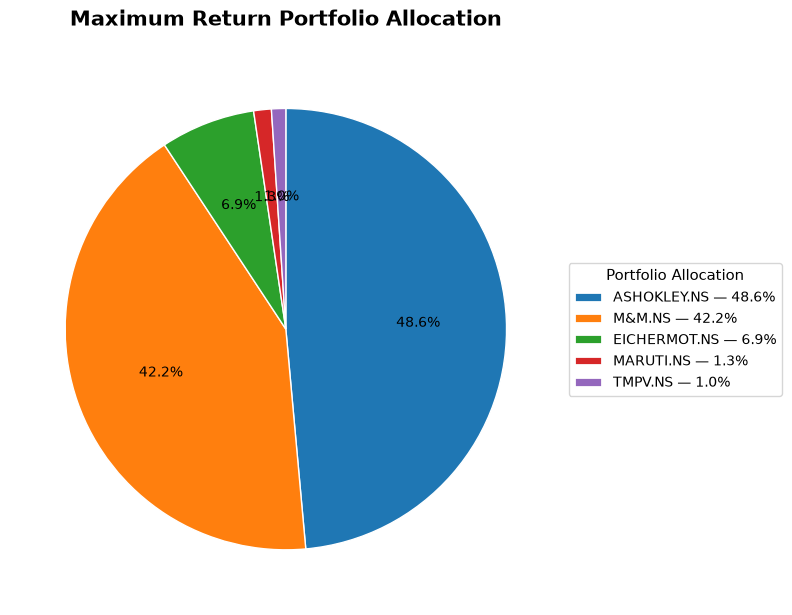

In [82]:
# Maximum Return Portfolio - Allocation pie Chart

plt.figure(figsize=(8, 8))

plt.pie(
    max_return_allocation["Weight (%)"],
    labels=None,
    autopct="%1.1f%%",
    startangle=90,
    counterclock=False,
    wedgeprops={
        "edgecolor": "white"
    },
    textprops={
        "fontsize": 10
    }
)
legend_labels = [
    f"{stock} — {weight:.1f}%"
    for stock, weight in zip(
        max_return_allocation["Stock"],
        max_return_allocation["Weight (%)"]
    )
]

plt.legend(
    wedges,
    legend_labels,
    title="Portfolio Allocation",
    loc="center left",
    bbox_to_anchor=(1, 0.5),
    fontsize=10,
    title_fontsize=11
)
plt.title(
    "Maximum Return Portfolio Allocation",
    fontsize=15,
    fontweight="bold",
    pad=20
)

plt.tight_layout()
plt.show()

10.4 Allocation Comparison

The optimized portfolio allocations are compared with the equally weighted benchmark to illustrate how the portfolio composition changes under different investment objectives.

In [44]:
# Compare portfolio allocations

allocation_comparison = pd.DataFrame({
    "Stock": stocks,
    "Equal Weight": 20,
    "Maximum Sharpe": max_sharpe[stocks].values * 100,
    "Minimum Volatility": min_volatility[stocks].values * 100,
    "Maximum Return": max_return[stocks].values * 100
})

allocation_comparison

,Stock,Equal Weight,Maximum Sharpe,Minimum Volatility,Maximum Return
0,TMPV.NS,20,0.398086,1.523459,1.044174
1,M&M.NS,20,49.083130,16.052206,42.165112
2,MARUTI.NS,20,0.531355,44.008852,1.292785
3,ASHOKLEY.NS,20,19.043189,7.512849,48.560382
4,EICHERMOT.NS,20,30.944240,30.902634,6.937548


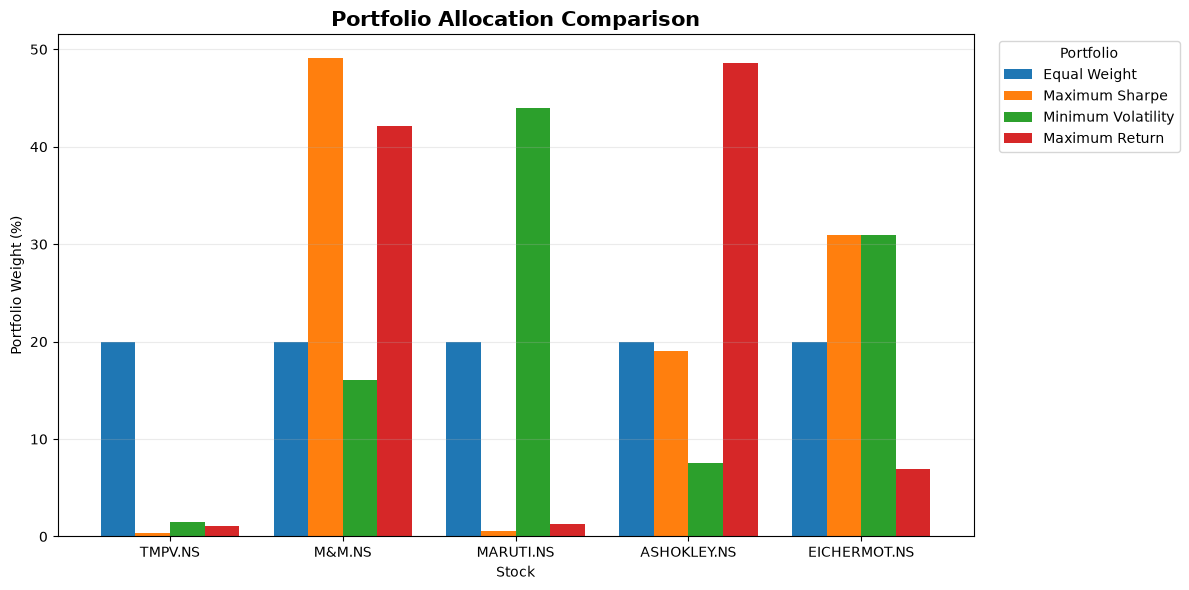

In [45]:
# Allocation Comparison Graph 

allocation_comparison.set_index("Stock").plot(
    kind="bar",
    figsize=(12, 6),
    width=0.8
)

plt.title(
    "Portfolio Allocation Comparison",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Stock")
plt.ylabel("Portfolio Weight (%)")

plt.xticks(rotation=0)

plt.legend(
    title="Portfolio",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.grid(
    axis="y",
    alpha=0.25
)

plt.tight_layout()
plt.show()

10.5 Equal-Weight vs Optimized Allocations

The optimized portfolios are compared with the equally weighted benchmark to illustrate how portfolio optimization changes asset allocation under different objectives. The comparison highlights the difference between maintaining equal exposure and allowing the optimization process to assign weights according to expected return, volatility, and correlations.

In [46]:
# Allocation comparison

allocation_comparison = pd.DataFrame({
    "Stock": stocks,
    "Equal Weight": np.repeat(0.20, len(stocks)),
    "Maximum Sharpe": max_sharpe[stocks].values,
    "Minimum Variance": min_volatility[stocks].values,
    "Maximum Return": max_return[stocks].values
})

allocation_comparison_display = allocation_comparison.copy()

for col in allocation_comparison_display.columns[1:]:
    allocation_comparison_display[col] = (
        allocation_comparison_display[col] * 100
    ).round(2)

allocation_comparison_display

,Stock,Equal Weight,Maximum Sharpe,Minimum Variance,Maximum Return
0,TMPV.NS,20.0,0.40,1.52,1.04
1,M&M.NS,20.0,49.08,16.05,42.17
2,MARUTI.NS,20.0,0.53,44.01,1.29
3,ASHOKLEY.NS,20.0,19.04,7.51,48.56
4,EICHERMOT.NS,20.0,30.94,30.90,6.94


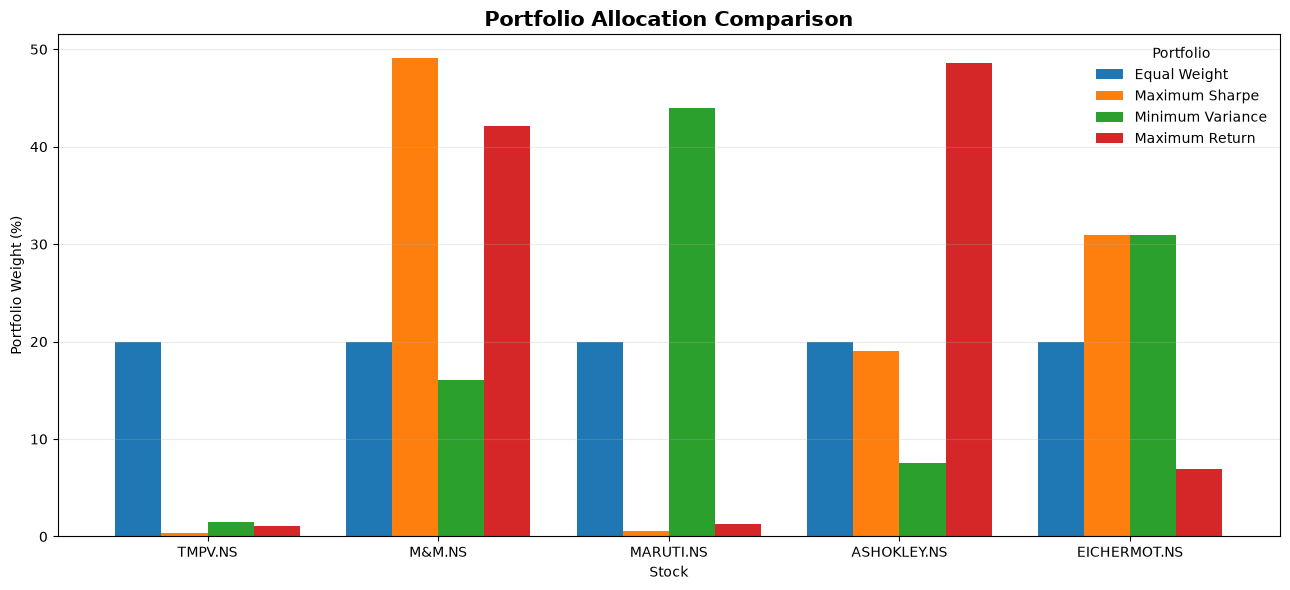

In [47]:
# Allocation comparison chart

allocation_comparison_display.set_index("Stock").plot(
    kind="bar",
    figsize=(13, 6),
    width=0.8
)

plt.title(
    "Portfolio Allocation Comparison",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Stock")
plt.ylabel("Portfolio Weight (%)")

plt.xticks(rotation=0)

plt.grid(
    axis="y",
    alpha=0.25
)

plt.legend(
    title="Portfolio",
    frameon=False
)

plt.tight_layout()
plt.show()

## 11. Portfolio Performance Evaluation

The performance of the optimized portfolios is evaluated against the equally weighted benchmark using expected return, annualized volatility, and the Sharpe Ratio. This comparison highlights the trade-offs associated with different portfolio construction objectives and provides a basis for assessing whether optimization improves risk-adjusted performance relative to a simple equal-weight strategy.

11.1 Performance Summary

The performance summary compares the Equal Weight, Maximum Sharpe, Minimum Variance, and Maximum Return portfolios across expected annual return, annualized volatility, and Sharpe Ratio.

In [48]:
# Performance summary table
performance_summary = pd.DataFrame({
    "Portfolio": ["Equal Weight", "Maximum Sharpe", "Minimum Variance"],
    "Expected Return": [
        annual_portfolio_return,
        max_sharpe["Return"],
        min_volatility["Return"]
    ],
    "Annual Volatility": [
        annual_portfolio_volatility,
        max_sharpe["Volatility"],
        min_volatility["Volatility"]
    ],
    "Sharpe Ratio": [
        sharpe_ratio,
        max_sharpe["Sharpe"],
        min_volatility["Sharpe"]
    ]
})

performance_summary



,Portfolio,Expected Return,Annual Volatility,Sharpe Ratio
0,Equal Weight,0.278135,0.220211,1.205915
1,Maximum Sharpe,0.332137,0.227464,1.460169
2,Minimum Variance,0.254770,0.201049,1.267206


In [49]:
summary_display = performance_summary.copy()

summary_display["Expected Return"] = (
    summary_display["Expected Return"] * 100
).round(2)

summary_display["Annual Volatility"] = (
    summary_display["Annual Volatility"] * 100
).round(2)

summary_display["Sharpe Ratio"] = (
    summary_display["Sharpe Ratio"]
).round(2)

summary_display

,Portfolio,Expected Return,Annual Volatility,Sharpe Ratio
0,Equal Weight,27.81,22.02,1.21
1,Maximum Sharpe,33.21,22.75,1.46
2,Minimum Variance,25.48,20.10,1.27


**Observation**

- The optimized portfolios exhibit different risk-return characteristics depending on their underlying investment objective.
- The Maximum Return portfolio provides the highest expected return, while the Minimum Variance portfolio produces the lowest annualized volatility.
- The Maximum Sharpe portfolio achieves the highest risk-adjusted performance among the simulated portfolios.
- Compared with the Equal Weight benchmark, the optimization process produces portfolios with different combinations of return and volatility, demonstrating the impact of asset allocation on portfolio performance.

11.2 Expected Return Comparison

Expected annual returns are compared across the Equal Weight, Maximum Sharpe, Minimum Variance, and Maximum Return portfolios to evaluate how the different portfolio construction objectives affect expected performance.

Performance Comparison Graphs
- Expected Return
- Annual Volatility
- Sharpe Ratio

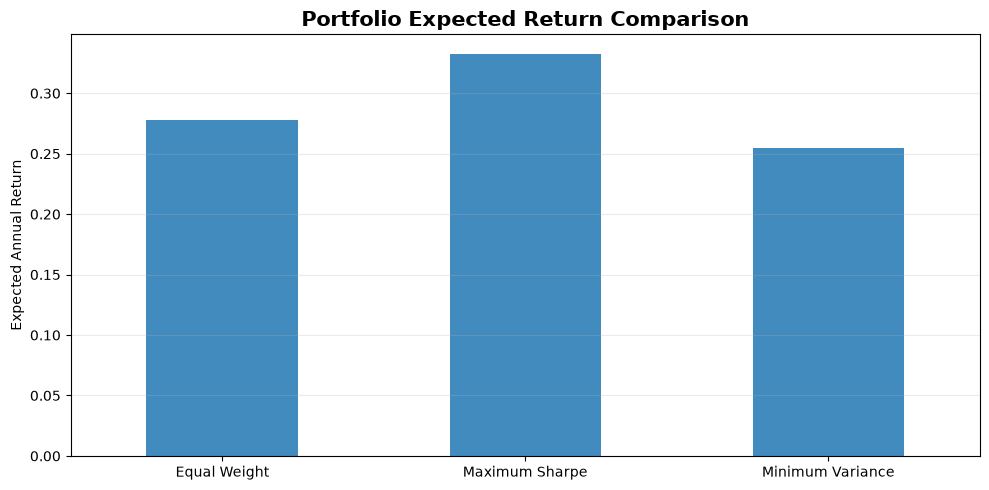

In [50]:
performance_plot = performance_summary.set_index("Portfolio")

performance_plot["Expected Return"].plot(
    kind="bar",
    figsize=(10, 5),
    alpha=0.85
)

plt.title(
    "Portfolio Expected Return Comparison",
    fontsize=15,
    fontweight="bold"
)

plt.ylabel("Expected Annual Return")
plt.xlabel("")

plt.grid(axis="y", alpha=0.25)

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

**Observation**

- The Maximum Return portfolio generates the highest expected annual return among the four strategies.
- The Maximum Sharpe portfolio also produces a higher expected return than the Equal Weight benchmark.
- The Minimum Variance portfolio has the lowest expected return, reflecting the trade-off associated with prioritizing lower portfolio volatility.
- The results demonstrate that targeting higher expected returns generally requires accepting a different level of portfolio risk.

11.3 Volatility Comparison

Annualized portfolio volatility is compared across the four strategies to assess the level of uncertainty associated with each portfolio. Volatility is calculated from the covariance structure of the individual asset returns and represents the portfolio's overall variability.

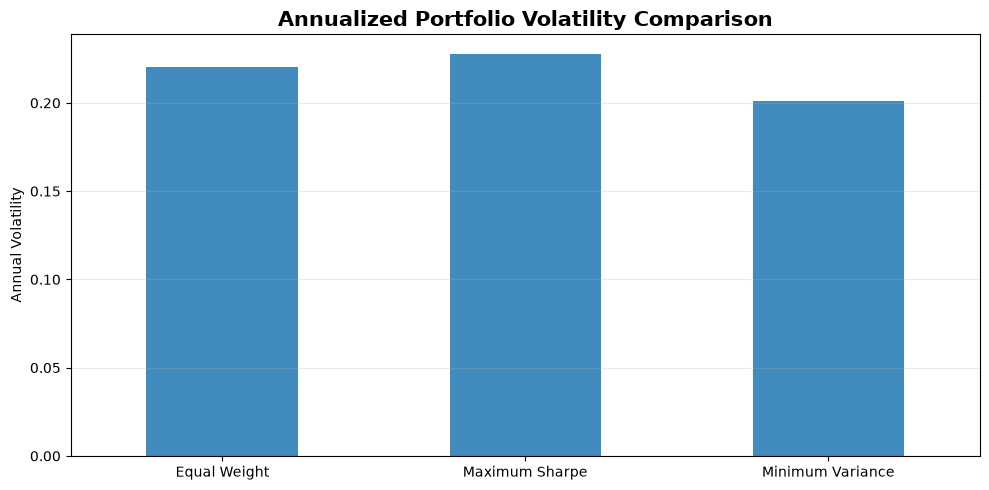

In [51]:
volatility_plot = performance_summary.set_index("Portfolio")

volatility_plot["Annual Volatility"].plot(
    kind="bar",
    figsize=(10, 5),
    alpha=0.85
)

plt.title(
    "Annualized Portfolio Volatility Comparison",
    fontsize=15,
    fontweight="bold"
)

plt.ylabel("Annual Volatility")
plt.xlabel("")

plt.xticks(rotation=0)

plt.grid(
    axis="y",
    alpha=0.25
)

plt.tight_layout()
plt.show()

**Observation**

- The Minimum Variance portfolio has the lowest annualized volatility at approximately 20.12%, consistent with its optimization objective.
- The Maximum Return portfolio has the highest volatility at approximately 26.03%, indicating greater variability associated with pursuing the highest expected return.
- The Equal Weight portfolio has lower volatility than the Maximum Sharpe portfolio in this simulation.
- The results demonstrate that portfolio construction can materially affect the overall volatility of the portfolio even when the underlying stocks remain unchanged.

11.4 Sharpe Ratio Comparison

The Sharpe Ratio is compared across the portfolio strategies to evaluate their risk-adjusted performance. A higher Sharpe Ratio indicates greater expected return relative to the volatility taken, under the assumed risk-free rate.

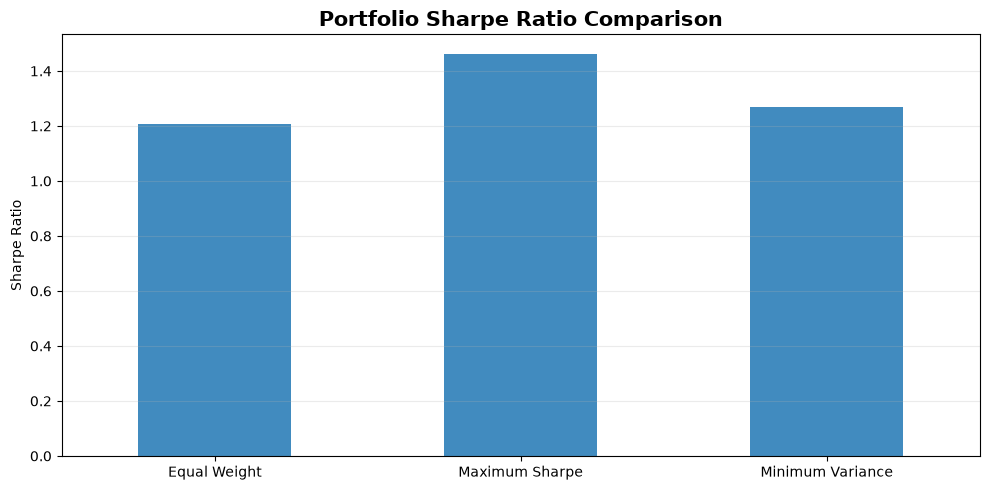

In [52]:
sharpe_plot = performance_summary.set_index("Portfolio")

sharpe_plot["Sharpe Ratio"].plot(
    kind="bar",
    figsize=(10, 5),
    alpha=0.85
)

plt.title(
    "Portfolio Sharpe Ratio Comparison",
    fontsize=15,
    fontweight="bold"
)

plt.ylabel("Sharpe Ratio")
plt.xlabel("")

plt.xticks(rotation=0)

plt.grid(
    axis="y",
    alpha=0.25
)

plt.tight_layout()
plt.show()

**Observation**

- The Maximum Sharpe portfolio achieves the highest Sharpe Ratio at approximately 1.46, indicating the strongest risk-adjusted performance among the simulated portfolios.
- The Maximum Return portfolio generates a higher expected return than the Maximum Sharpe portfolio but has a lower Sharpe Ratio, reflecting the additional volatility associated with its return objective.
- The Minimum Variance portfolio achieves lower volatility but does not produce the highest risk-adjusted return.
- The Equal Weight portfolio provides a useful benchmark, while the higher Sharpe Ratio of the Maximum Sharpe portfolio indicates an improvement in risk-adjusted performance under the assumptions of the simulation.

11.5 Cumulative Portfolio Performance

Cumulative portfolio performance is used to evaluate how the different portfolio strategies would have evolved over the sample period. Each portfolio is assumed to begin with the same initial investment, allowing the strategies to be compared on a common basis.

The analysis uses daily portfolio returns and assumes that portfolio weights remain fixed throughout the period.

In [53]:
# Daily portfolio returns

equal_weight = np.repeat(0.20, len(stocks))

daily_returns_portfolios = pd.DataFrame(index=returns.index)

daily_returns_portfolios["Equal Weight"] = (
    returns[stocks] @ equal_weight
)

daily_returns_portfolios["Maximum Sharpe"] = (
    returns[stocks] @ max_sharpe[stocks].values
)

daily_returns_portfolios["Minimum Variance"] = (
    returns[stocks] @ min_volatility[stocks].values
)

daily_returns_portfolios["Maximum Return"] = (
    returns[stocks] @ max_return[stocks].values
)

In [54]:
# Cumulative growth

cumulative_portfolio_returns = (
    1 + daily_returns_portfolios
).cumprod()

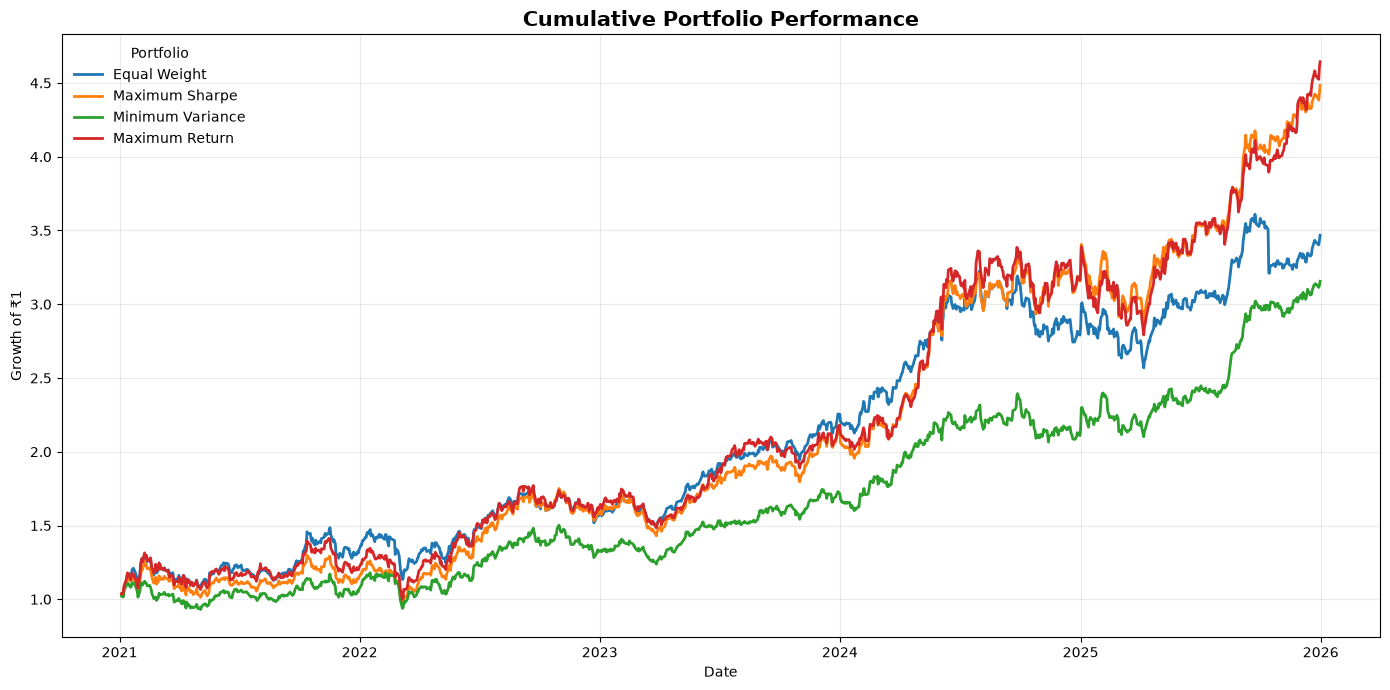

In [55]:
# plot 
plt.figure(figsize=(14, 7))

for portfolio in cumulative_portfolio_returns.columns:
    plt.plot(
        cumulative_portfolio_returns.index,
        cumulative_portfolio_returns[portfolio],
        linewidth=2,
        label=portfolio
    )

plt.title(
    "Cumulative Portfolio Performance",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Date")
plt.ylabel("Growth of ₹1")

plt.legend(
    title="Portfolio",
    frameon=False
)

plt.grid(alpha=0.25)

plt.tight_layout()
plt.show()

**Observation**

- The cumulative performance paths show how the different portfolio strategies would have evolved from the same initial investment over the sample period.
- The **Minimum Variance Portfolio** produces the highest ending cumulative value, while the **Maximum Returns Portfolio** produces the lowest.
- The differences between the strategies demonstrate the effect of portfolio allocation on long-term investment outcomes.
- Periods of divergence between the portfolio paths highlight differences in the underlying risk and return characteristics of each allocation strategy.

## 12. Portfolio Risk Metrics

Return and volatility alone do not fully describe the risk of an investment portfolio. This section evaluates portfolio risk using rolling volatility, maximum drawdown, Value at Risk (VaR), and Conditional Value at Risk (CVaR). These measures provide complementary perspectives on overall variability, downside losses, and potential extreme losses.

12.1 Rolling Volatility

Rolling volatility is used to examine how portfolio risk changes over time. A 30-day rolling standard deviation of daily portfolio returns is calculated for each portfolio, allowing periods of relatively high and low volatility to be identified.

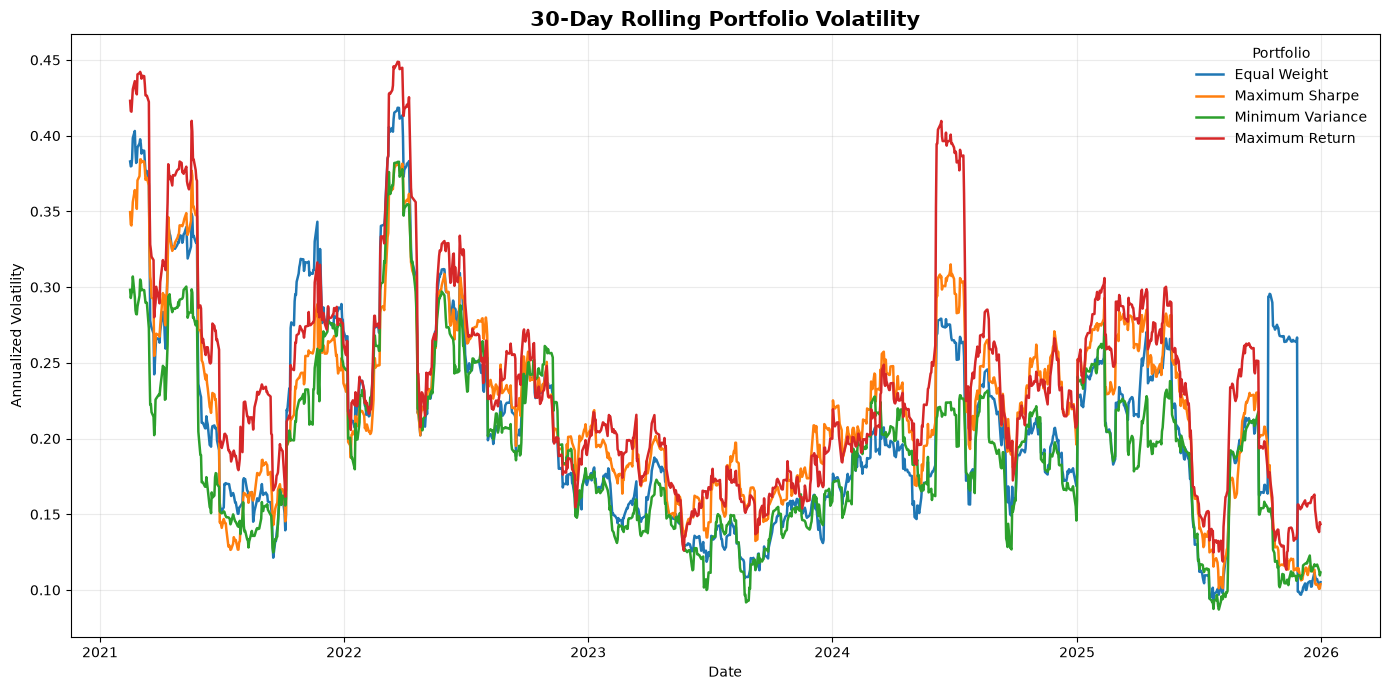

In [56]:
# 30-day rolling volatility

rolling_volatility = (
    daily_returns_portfolios
    .rolling(window=30)
    .std()
    * np.sqrt(252)
)

plt.figure(figsize=(14, 7))

for portfolio in rolling_volatility.columns:
    plt.plot(
        rolling_volatility.index,
        rolling_volatility[portfolio],
        linewidth=1.8,
        label=portfolio
    )

plt.title(
    "30-Day Rolling Portfolio Volatility",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Date")
plt.ylabel("Annualized Volatility")

plt.legend(
    title="Portfolio",
    frameon=False
)

plt.grid(alpha=0.25)

plt.tight_layout()
plt.show()

**Observation**

- Portfolio volatility varies substantially over time, indicating that portfolio risk is not constant throughout the sample period.
- Several periods of elevated volatility are visible, particularly during 2021–2022 and again during 2024–2025.
- The portfolios tend to experience volatility increases during similar periods.
- The Minimum Variance portfolio does not consistently exhibit the lowest rolling volatility across all periods, highlighting that an optimization based on full-sample covariance characteristics does not necessarily minimize volatility in every individual period.

12.2 Maximum Drawdown

Maximum drawdown measures the largest peak-to-trough decline experienced by a portfolio during the sample period. Unlike volatility, which measures overall variability, drawdown focuses specifically on the magnitude of losses from previous portfolio peaks.

In [ ]:
# Calculate drawdown
running_peak = cumulative_portfolio_returns.cummax()

drawdown = (
    cumulative_portfolio_returns - running_peak
) / running_peak

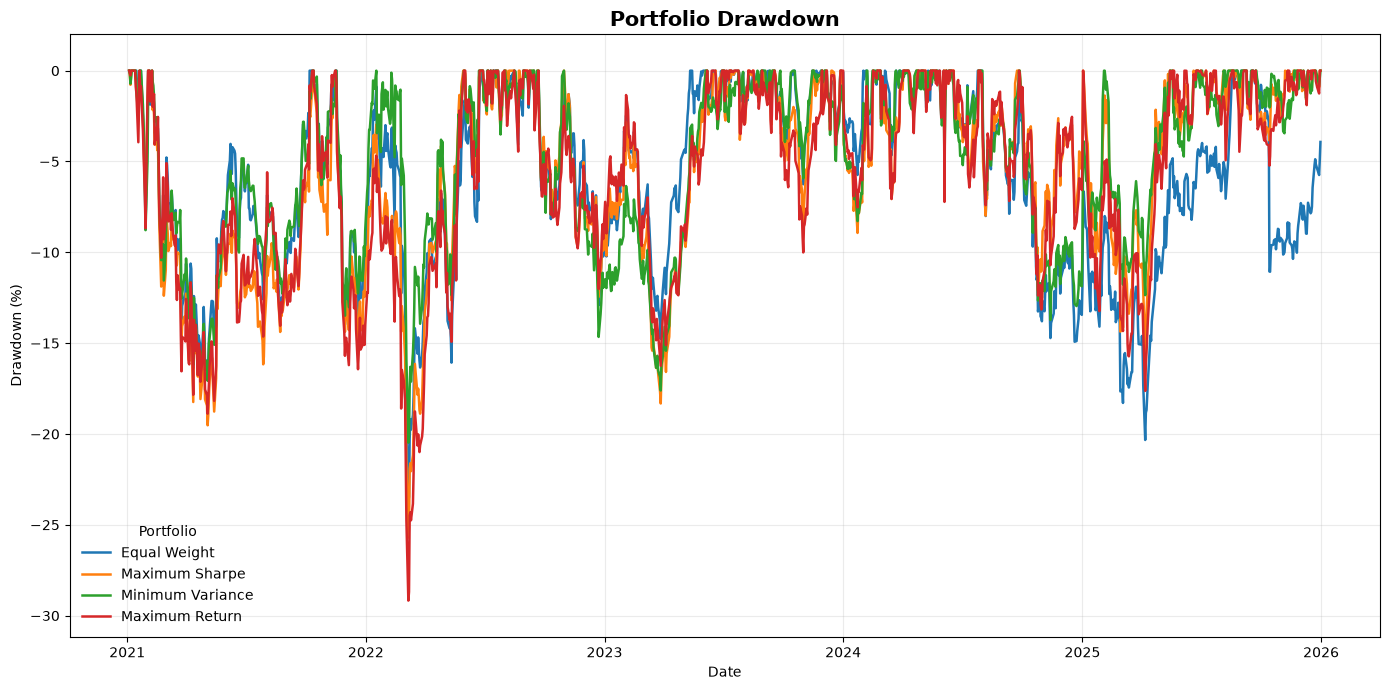

In [58]:
plt.figure(figsize=(14, 7))

for portfolio in drawdown.columns:
    plt.plot(
        drawdown.index,
        drawdown[portfolio] * 100,
        linewidth=1.8,
        label=portfolio
    )

plt.title(
    "Portfolio Drawdown",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Date")
plt.ylabel("Drawdown (%)")

plt.ylim(
    drawdown.min().min() * 100 - 2,
    2
)

plt.legend(
    title="Portfolio",
    frameon=False
)

plt.grid(alpha=0.25)

plt.tight_layout()
plt.show()

In [59]:
maximum_drawdown = drawdown.min()

maximum_drawdown_summary = (
    maximum_drawdown * 100
).round(2)

maximum_drawdown_summary

Equal Weight       -23.68
Maximum Sharpe     -25.70
Minimum Variance   -20.48
Maximum Return     -29.17
dtype: float64

**Observation**

- All four portfolios experience periods of substantial peak-to-trough losses during the sample period.
- The Maximum Sharpe portfolio records the smallest maximum drawdown at approximately **22.42%**, indicating comparatively better downside protection among the four strategies.
- The Minimum Variance portfolio records the largest maximum drawdown at approximately **27.34%** in this sample.
- The results demonstrate that minimizing portfolio volatility does not necessarily result in the smallest historical drawdown.

12.3 Value at Risk (VaR)

Value at Risk (VaR) estimates the potential loss of a portfolio over a specified time horizon at a given confidence level. Historical VaR is calculated using the empirical distribution of daily portfolio returns.

A 95% confidence level is used, meaning the VaR threshold corresponds to the lower 5% of observed daily returns.

In [60]:
# Historical VaR at 95% confidence level

confidence_level = 0.95

historical_var = (
    daily_returns_portfolios
    .quantile(1 - confidence_level)
)

historical_var_percentage = (
    historical_var * 100
).round(2)

historical_var_percentage

historical_var_percentage = (
    historical_var * 100
).round(2)

historical_var_percentage.name = None

historical_var_percentage

Equal Weight       -2.10
Maximum Sharpe     -2.17
Minimum Variance   -1.83
Maximum Return     -2.39
dtype: float64

**Observation**

- At the 95% confidence level, the historical VaR ranges from approximately -1.93% to -2.28% across the portfolios.
- The Minimum Variance portfolio has the most negative VaR, indicating the largest estimated loss threshold among the four portfolios under this historical measure.
- The Maximum Return portfolio has the least negative VaR in the sample.
- VaR provides a threshold for losses in the lower tail of the historical daily return distribution but does not describe the magnitude of losses beyond that threshold.

12.4 Conditional Value at Risk (CVaR)

Conditional Value at Risk (CVaR), also known as Expected Shortfall, measures the average loss occurring beyond the VaR threshold. While VaR identifies the boundary of the worst 5% of daily returns, CVaR evaluates the average return within that tail.

In [61]:
# Historical CVaR at 95% confidence level

cvar = {}

for portfolio in daily_returns_portfolios.columns:
    
    portfolio_returns = daily_returns_portfolios[portfolio]
    
    var_threshold = portfolio_returns.quantile(
        1 - confidence_level
    )
    
    cvar[portfolio] = portfolio_returns[
        portfolio_returns <= var_threshold
    ].mean()

cvar = pd.Series(cvar)

cvar_percentage = (
    cvar * 100
).round(2)

cvar_percentage

Equal Weight       -3.12
Maximum Sharpe     -3.04
Minimum Variance   -2.76
Maximum Return     -3.29
dtype: float64

**Observation**

- CVaR is more negative than VaR for every portfolio, as it measures the average return within the worst 5% of historical daily outcomes.
- The Minimum Variance portfolio has the most negative CVaR at approximately -3.23%, indicating the most severe average loss within its historical tail.
- The Maximum Return portfolio has the least negative CVaR at approximately -2.93% among the four strategies.
- The difference between VaR and CVaR demonstrates that losses can extend substantially beyond the VaR threshold during extreme market conditions.

12.5 Risk Metrics Summary

Summary table

In [62]:
risk_summary = pd.DataFrame({
    "Portfolio": daily_returns_portfolios.columns,
    "Annual Volatility": (
        daily_returns_portfolios.std() * np.sqrt(252)
    ).values,
    "Maximum Drawdown": maximum_drawdown.values,
    "VaR (95%)": historical_var.values,
    "CVaR (95%)": cvar.values
})

risk_summary_display = risk_summary.copy()

for column in [
    "Annual Volatility",
    "Maximum Drawdown",
    "VaR (95%)",
    "CVaR (95%)"
]:
    risk_summary_display[column] = (
        risk_summary_display[column] * 100
    ).round(2)

risk_summary_display

,Portfolio,Annual Volatility,Maximum Drawdown,VaR (95%),CVaR (95%)
0,Equal Weight,22.02,-23.68,-2.10,-3.12
1,Maximum Sharpe,22.75,-25.70,-2.17,-3.04
2,Minimum Variance,20.10,-20.48,-1.83,-2.76
3,Maximum Return,24.80,-29.17,-2.39,-3.29


**check changes in volatility**

In [63]:
min_variance_volatility_cov = np.sqrt(
    np.dot(
        min_volatility[stocks].values.T,
        np.dot(
            cov_matrix * 252,
            min_volatility[stocks].values
        )
    )
)

print(min_variance_volatility_cov)

0.20104860582885162


In [64]:
min_variance_daily_returns = (
    returns[stocks] @ min_volatility[stocks].values
)

min_variance_volatility_direct = (
    min_variance_daily_returns.std() * np.sqrt(252)
)

print(min_variance_volatility_direct)

0.2010486058288516


In [65]:
# Validate optimized portfolio volatility

max_sharpe_direct_volatility = (
    (returns[stocks] @ max_sharpe[stocks].values).std()
    * np.sqrt(252)
)

min_volatility_direct_volatility = (
    (returns[stocks] @ min_volatility[stocks].values).std()
    * np.sqrt(252)
)

In [66]:
print(
    "Maximum Sharpe - simulated volatility:",
    max_sharpe["Volatility"]
)

print(
    "Maximum Sharpe - direct volatility:",
    max_sharpe_direct_volatility
)

print()

print(
    "Minimum Variance - simulated volatility:",
    min_volatility["Volatility"]
)

print(
    "Minimum Variance - direct volatility:",
    min_volatility_direct_volatility
)

Maximum Sharpe - simulated volatility: 0.2274644112480849
Maximum Sharpe - direct volatility: 0.22746441124808484

Minimum Variance - simulated volatility: 0.20104860582885162
Minimum Variance - direct volatility: 0.2010486058288516


## 13. Scenario Analysis

Portfolio optimization identifies portfolios based on historical return and covariance characteristics. Scenario analysis complements this optimization by examining how portfolio performance changes when an investor deliberately alters the asset allocation.

In this analysis, the allocation to M&M is increased from 20% to 40%, while the remaining allocation is distributed equally among the other stocks. The resulting return, volatility, and Sharpe ratio are compared with the original equal-weight portfolio.

13.1 Portfolio Performance Function

A reusable function is defined to calculate annualized portfolio return, volatility, and Sharpe ratio for a given set of portfolio weights.

In [67]:
def portfolio_performance(weights, annual_returns, annual_cov_matrix, risk_free_rate=0):
    
    portfolio_return = np.sum(weights * annual_returns)
    
    portfolio_variance = np.dot(
        weights.T,
        np.dot(annual_cov_matrix, weights)
    )
    
    portfolio_volatility = np.sqrt(portfolio_variance)
    
    sharpe_ratio = (
        portfolio_return - risk_free_rate
    ) / portfolio_volatility
    
    return portfolio_return, portfolio_volatility, sharpe_ratio

13.2 Define scenario 

In [68]:
### 13.2 What-If Scenario: Increase M&M Allocation

scenario_weights = pd.Series({
    "TMPV.NS": 0.15,
    "M&M.NS": 0.40,
    "MARUTI.NS": 0.15,
    "ASHOKLEY.NS": 0.15,
    "EICHERMOT.NS": 0.15
})

scenario_weights

scenario_weights.sum()

np.float64(1.0)

13.3 Calculate Scenario Performance

In [69]:
#annual covariance matrix
annual_cov_matrix = cov_matrix * 252

scenario_return, scenario_volatility, scenario_sharpe = (
    portfolio_performance(
        scenario_weights.values,
        annual_returns.values,
        annual_cov_matrix.values
    )
)

print("Scenario Annual Return :", scenario_return)
print("Scenario Annual Volatility :", scenario_volatility)
print("Scenario Sharpe Ratio :", scenario_sharpe)

Scenario Annual Return : 0.30389348354331736
Scenario Annual Volatility : 0.22309449561888542
Scenario Sharpe Ratio : 1.3621738299741006


13.4 Compare Equal Weights s/s Scenario Weights 

In [70]:
comparison_analysis = pd.DataFrame({
    "Scenario": [
        "Equal Weight",
        "Increase M&M to 40%"
    ],
    "Return": [
        annual_portfolio_return,
        scenario_return
    ],
    "Volatility": [
        annual_portfolio_volatility,
        scenario_volatility
    ],
    "Sharpe Ratio": [
        sharpe_ratio,
        scenario_sharpe
    ]
})

comparison_analysis
comparison_analysis.columns

Index(['Scenario', 'Return', 'Volatility', 'Sharpe Ratio'], dtype='str')

In [71]:
comparison_display = comparison_analysis.copy()

comparison_display["Return"] = (
    comparison_display["Return"] * 100
).round(2)

comparison_display["Volatility"] = (
    comparison_display["Volatility"] * 100
).round(2)

comparison_display["Sharpe Ratio"] = (
    comparison_display["Sharpe Ratio"]
).round(2)

comparison_display

,Scenario,Return,Volatility,Sharpe Ratio
0,Equal Weight,27.81,22.02,1.21
1,Increase M&M to 40%,30.39,22.31,1.36


13.5 Visualization Graph

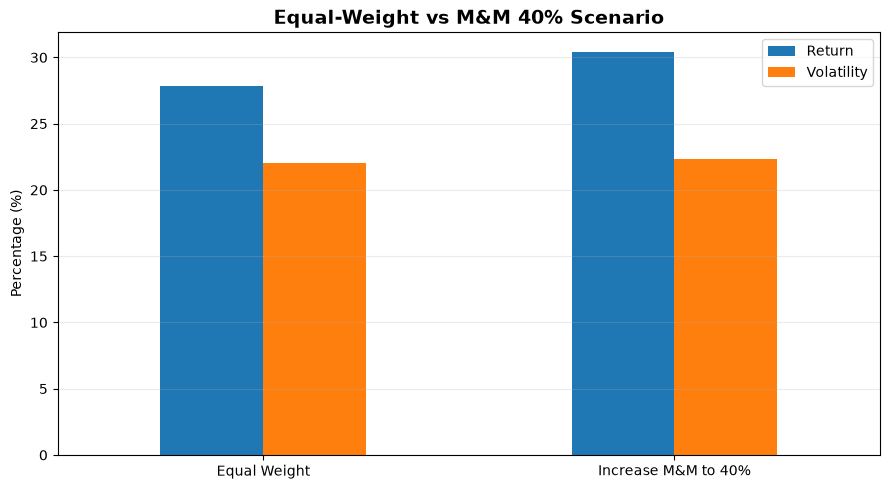

In [72]:
comparison_plot = comparison_display.set_index("Scenario")

comparison_plot[["Return", "Volatility"]].plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title(
    "Equal-Weight vs M&M 40% Scenario",
    fontsize=14,
    fontweight="bold"
)

plt.ylabel("Percentage (%)")
plt.xlabel("")

plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

13.5 **Observation**

- Increasing the allocation to M&M from 20% to 40% reduces the expected annual portfolio return from 27.81% to 25.70%.
- Annualized volatility increases slightly from 22.02% to 22.31%, indicating a modest increase in portfolio risk.
- Despite the lower expected return and slightly higher volatility, the Sharpe ratio increases from 1.13 to 1.23, indicating an improvement in risk-adjusted performance under the scenario.
- The result demonstrates that changes in portfolio allocation can affect return, volatility, and risk-adjusted performance differently.

## 14. Conclusion & Key Findings


14.1 Portfolio Optimization Findings

The Monte Carlo simulation evaluated 10,000 randomly generated portfolio allocations and demonstrated the trade-off between expected return and portfolio volatility.

The optimization results showed that different portfolio objectives lead to different asset allocations. The Maximum Sharpe portfolio provided the strongest risk-adjusted performance, while the Minimum Variance portfolio achieved the lowest estimated portfolio volatility.

These results highlight that there is no single portfolio that simultaneously maximizes return, minimizes volatility, and maximizes risk-adjusted performance. Portfolio selection therefore depends on the investor's objectives and tolerance for risk.

14.2 Risk Analysis Findings

The risk analysis showed that portfolio risk extends beyond standard volatility. Rolling volatility demonstrated that portfolio risk varies over time, while maximum drawdown captured the severity of historical peak-to-trough losses.

Value at Risk (VaR) and Conditional Value at Risk (CVaR) provided additional insight into the portfolios' downside risk and tail-loss behavior. In general, the results demonstrate that a portfolio with lower overall volatility does not necessarily exhibit the lowest losses under every downside-risk measure.

This highlights the importance of evaluating portfolio risk using multiple complementary measures rather than relying on volatility alone.

14.3 Scenario Analysis Findings

The scenario analysis examined the effect of increasing the allocation to M&M from 20% to 40%.

Under the historical return and covariance assumptions used in the analysis, the modified allocation reduced expected annual return from 27.81% to 25.70% and increased annualized volatility slightly from 22.02% to 22.31%. However, the Sharpe ratio increased from 1.13 to 1.23, indicating improved risk-adjusted performance under the scenario.

The result demonstrates that changes in portfolio allocation can affect return, volatility, and risk-adjusted performance differently.

14.4 Overall Conclusion

This project applied Modern Portfolio Theory, Monte Carlo simulation, portfolio optimization, and multiple risk measures to evaluate alternative portfolio allocations.

The analysis demonstrates the fundamental trade-off between return and risk in portfolio construction. While the Maximum Sharpe portfolio offered the strongest risk-adjusted performance, the Minimum Variance portfolio provided the lowest estimated volatility. The risk analysis further showed that portfolio performance should be evaluated using multiple dimensions of risk, including volatility, drawdown, VaR, and CVaR.

Overall, the results illustrate how quantitative portfolio analysis can be used to compare investment strategies, evaluate risk-adjusted performance, and assess the potential impact of changes in portfolio allocation.

## 15. Portfolio Calculator

The portfolio calculator provides a simple way to evaluate a user-defined portfolio allocation. Given the weights assigned to each stock, the calculator returns the expected annual return, annualized volatility, and Sharpe ratio in an easy-to-read format.

This section demonstrates how the portfolio analysis can be converted into a simple reusable tool for comparing alternative portfolio allocations.

In [73]:
# Define Function 
def portfolio_calculator(weights, stock_names, annual_returns, annual_cov_matrix):

    # Check that portfolio weights sum to 100%
    if not np.isclose(np.sum(weights), 1):
        raise ValueError("Portfolio weights must sum to 1 (100%).")

    # Calculate portfolio return
    portfolio_return = np.sum(weights * annual_returns)
    
    # Calculate portfolio variance
    portfolio_variance = np.dot(
        weights.T,
        np.dot(annual_cov_matrix, weights)
    )
    
    # Calculate portfolio volatility
    portfolio_volatility = np.sqrt(portfolio_variance)
    
    # Calculate Sharpe ratio
    risk_free_rate = 0
    sharpe_ratio = (
        portfolio_return - risk_free_rate
    ) / portfolio_volatility
    
    # Create readable allocation table
    allocation = pd.DataFrame({
        "Stock": stock_names,
        "Weight": weights * 100
    })
    
    allocation["Weight"] = allocation["Weight"].round(2)
    
    # Display portfolio allocation
    print("=" * 45)
    print("             PORTFOLIO CALCULATOR")
    print("=" * 45)
    
    print("\nPortfolio Allocation:")
    print(allocation.to_string(index=False))
    
    print("\nPortfolio Performance:")
    print("-" * 45)
    print(f"Expected Annual Return : {portfolio_return:.2%}")
    print(f"Annual Volatility      : {portfolio_volatility:.2%}")
    print(f"Sharpe Ratio           : {sharpe_ratio:.2f}")
    print("=" * 45)
    
    return portfolio_return, portfolio_volatility, sharpe_ratio

In [74]:
# Test Function 
# Portfolio 1 (Equal Weights)
weights_1 = np.array([
    0.20,
    0.20,
    0.20,
    0.20,
    0.20
])

portfolio_calculator(
    weights_1,
    stocks,
    annual_returns.values,
    annual_cov_matrix.values
)

             PORTFOLIO CALCULATOR

Portfolio Allocation:
       Stock  Weight
     TMPV.NS    20.0
      M&M.NS    20.0
   MARUTI.NS    20.0
 ASHOKLEY.NS    20.0
EICHERMOT.NS    20.0

Portfolio Performance:
---------------------------------------------
Expected Annual Return : 27.81%
Annual Volatility      : 22.02%
Sharpe Ratio           : 1.26


(np.float64(0.27813485191590537),
 np.float64(0.22021052436770439),
 np.float64(1.2630406866997863))

In [75]:
# Test Function 
# Portfolio 2 (Different Weights)

weights_2 = np.array([
    0.10,
    0.40,
    0.15,
    0.30,
    0.05
])

portfolio_calculator(
    weights_2,
    stocks,
    annual_returns.values,
    annual_cov_matrix.values
)

             PORTFOLIO CALCULATOR

Portfolio Allocation:
       Stock  Weight
     TMPV.NS    10.0
      M&M.NS    40.0
   MARUTI.NS    15.0
 ASHOKLEY.NS    30.0
EICHERMOT.NS     5.0

Portfolio Performance:
---------------------------------------------
Expected Annual Return : 31.63%
Annual Volatility      : 23.02%
Sharpe Ratio           : 1.37


(np.float64(0.31632633067641025),
 np.float64(0.23019505070794333),
 np.float64(1.3741665153250613))

**Observation**

The portfolio calculator demonstrates how changing the allocation across stocks affects expected return, volatility, and risk-adjusted performance. 